# TCL Pipeline 4 (Approach 4: Topic Embedding + Ruptures Grouping)

This notebook follows the same model/loss/evaluation/user-inference style as `TCL_Pipeline_new_1.ipynb`, but implements **Approach 4** with topic-embedding feature integration and **ruptures-based grouping** for temporal narrative shift detection.

## 1. Imports

This cell loads all required libraries, sets plotting defaults, and initializes the compute device.

What this prepares:
- numerical/data stack (`numpy`, `pandas`)
- deep learning stack (`torch`)
- progress/visualization utilities

In [1]:
import os
import json
import ast
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


/home/hp/SEM2/INLP/Naretve_Shift/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Config

This cell defines all runtime parameters grouped by purpose: paths, topic schema, feature settings, grouping strategy, inference controls, model architecture, training controls, drift thresholds, and reproducibility.

Goal: keep settings easy to audit and change without touching algorithm code.

In [2]:
# -----------------------------
# Config grouped by function
# -----------------------------

# 0) Alignment profile (keep new notebook structure, match old ap4 behavior)
alignment_settings = {
    "match_ap4_behavior": True,
    "topic_weight_threshold": 0.27,
}

# 1) Paths and I/O
path_settings = {
    "data_path": "/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Distributed_Data/BAL_TOPIC_WISE_W3",
    "output_path": "./tcl_output_new_4",
}

# 2) Topics and source files
topic_data_settings = {
    "topics": ["War", "Health", "Economics", "Technology", "Climate"],
    "topic_files": {
        "War": "War.csv",
        "Health": "Health.csv",
        "Economics": "Economics.csv",
        "Technology": "Technology.csv",
        "Climate": "Climate.csv",
    },
    "embedding_column": "w5_embedding",
}

# 3) Feature construction (AP4 dimensions)
feature_settings = {
    "embedding_dim": 768,
    "topic_embedding_dim": 64,
    "window_size": 4,
    "stride": 1,
    "context_window": 5,
    "min_sentences_per_day": 2,
    "daily_variance_alpha": 0.0,
}

# 4) Grouping strategy (Approach 4 uses ruptures only)
grouping_settings = {
    "ruptures_only": True,
    "ruptures_model": "rbf",
    "ruptures_penalty": 0.1,
    "ruptures_min_size": 2,
}

# 5) Inference controls
inference_settings = {
    "topic_threshold": 0.27,
    "inference_batch_size": 32,
}

# 6) Model architecture (AP4-equivalent)
model_settings = {
    "hidden_dim": 512,
    "num_heads": 8,
    "num_layers": 4,
    "feed_forward_dim": 2048,
    "dropout": 0.1,
    "projection_dim": 256,
}

# 7) Optimization and training
training_settings = {
    "batch_size": 128,
    "learning_rate": 3e-4,
    "epochs": 100,
    "weight_decay": 1e-5,
    "warmup_epochs": 5,
    "min_lr": 1e-6,
    "temperature": 0.05,
    "lambda_temporal": 1.5,
    "lambda_topic_sep": 0.7,
    "lambda_hard_neg": 0.3,
    "topic_sep_margin": 0.35,
    "hard_neg_margin": 0.25,
    "gradient_clip": 1.0,
    "use_amp": True,
    "patience": 5,
    "min_delta": 1e-3,
    "save_checkpoints": True,
    "checkpoint_freq": 5,
}

# 8) Drift/shift detection
# Keep shift_threshold_multiplier for compatibility with previous cells.
drift_settings = {
    "shift_threshold_multiplier": 1.5,
    "manual_shift_threshold": 0.1,
}

# 9) Runtime and reproducibility
runtime_settings = {
    "seed": 42,
}

# 10) Artifact naming and model interface
artifact_settings = {
    "approach_id": "4",
    "model_name_prefix": "approch",
    "model_type": "ruptures",
    "model_group_size": f"pen{str(grouping_settings['ruptures_penalty']).replace('.', 'p')}",
    "model_name_template": "{model_name_prefix}_{model_type}_{model_group_size}_{approach_id}_w{window_size}_s{stride}_t{temperature_tag}",
    "load_variant": "best",
}

config = {
    **alignment_settings,
    **path_settings,
    **topic_data_settings,
    **feature_settings,
    **grouping_settings,
    **inference_settings,
    **model_settings,
    **training_settings,
    **drift_settings,
    **runtime_settings,
    **artifact_settings,
}

# AP4-compatible uppercase aliases (names only) while preserving existing keys.
config.update({
    "TOPIC_WEIGHT_THRESHOLD": config["topic_weight_threshold"],
    "TOPIC_THRESHOLD": config["topic_threshold"],
    "WINDOW_SIZE": config["window_size"],
    "WINDOW_STRIDE": config["stride"],
    "TEMPERATURE": config["temperature"],
    "RUPTURES_PENALTY": config["ruptures_penalty"],
    "SHIFT_THRESHOLD_MULTIPLIER": config["shift_threshold_multiplier"],
    "MANUAL_SHIFT_THRESHOLD": config["manual_shift_threshold"],
    "INPUT_DIM": config["embedding_dim"] + config["topic_embedding_dim"],
    "MIN_SIZE": config["ruptures_min_size"],
})


def _temperature_tag(value):
    return str(value).replace(".", "p")


def build_model_base_name(cfg):
    return cfg["model_name_template"].format(
        model_name_prefix=cfg["model_name_prefix"],
        model_type=cfg["model_type"],
        model_group_size=cfg["model_group_size"],
        approach_id=cfg["approach_id"],
        window_size=cfg["window_size"],
        stride=cfg["stride"],
        temperature_tag=_temperature_tag(cfg["temperature"]),
    )


def build_artifact_paths(cfg):
    base_name = build_model_base_name(cfg)
    output_path = cfg["output_path"]
    paths = {
        "model_base_name": base_name,
        "model_best_path": os.path.join(output_path, f"{base_name}_best.pt"),
        "model_last_path": os.path.join(output_path, f"{base_name}_last.pt"),
        "model_evaluated_path": os.path.join(output_path, f"{base_name}_evaluated.pt"),
        "train_loss_plot_path": os.path.join(output_path, f"{base_name}_train_loss.png"),
        "eval_heatmap_intra_path": os.path.join(output_path, f"{base_name}_intra_heatmap.png"),
        "eval_heatmap_inter_path": os.path.join(output_path, f"{base_name}_inter_heatmap.png"),
        "run_summary_path": os.path.join(output_path, f"{base_name}_run_summary.json"),
        "eval_metrics_path": os.path.join(output_path, f"{base_name}_evaluation_metrics.json"),
    }

    variant_to_path = {
        "best": paths["model_best_path"],
        "last": paths["model_last_path"],
        "evaluated": paths["model_evaluated_path"],
    }
    load_variant = str(cfg.get("load_variant", "best")).lower().strip()
    paths["model_load_path"] = variant_to_path.get(load_variant, paths["model_best_path"])
    return paths


def load_checkpoint_compat(path, map_location):
    try:
        return torch.load(path, map_location=map_location)
    except Exception as exc:
        if "Weights only load failed" in str(exc):
            return torch.load(path, map_location=map_location, weights_only=False)
        raise


def build_topic_embedding_table(cfg):
    # AP4-like topic embedding setup: learned-layer equivalent initialization table (64-d per topic).
    rng_local = np.random.default_rng(cfg["seed"])
    table = rng_local.standard_normal((len(cfg["topics"]), cfg["topic_embedding_dim"]))
    table = table.astype(np.float32)
    table /= (np.linalg.norm(table, axis=1, keepdims=True) + 1e-8)
    return table


config["topic_prob_dim"] = len(config["topics"])
config["topic_dim"] = config["topic_embedding_dim"]
config["final_dim"] = config["embedding_dim"] + config["topic_embedding_dim"]

if config["context_window"] not in (3, 5):
    raise ValueError("config['context_window'] must be either 3 or 5")

if not config.get("ruptures_only", False):
    raise ValueError("Approach 4 is configured as ruptures-only grouping")

os.makedirs(config["output_path"], exist_ok=True)
config.update(build_artifact_paths(config))

np.random.seed(config["seed"])
torch.manual_seed(config["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config["seed"])

config["topic_embedding_table"] = build_topic_embedding_table(config)

print("Config ready")
print(
    f"final_dim={config['final_dim']} (={config['embedding_dim']}+{config['topic_embedding_dim']}) | topics={len(config['topics'])} | "
    f"window_size={config['window_size']} | context_window={config['context_window']}"
)
print(
    f"Grouping strategy: ruptures(model={config['ruptures_model']}, "
    f"penalty={config['ruptures_penalty']}, min_size={config['ruptures_min_size']})"
)
print(
    f"Loss weights: temporal={config['lambda_temporal']}, "
    f"topic_sep={config['lambda_topic_sep']}, hard_neg={config['lambda_hard_neg']}"
)
print(f"Topic threshold (train/infer alignment): {config['topic_weight_threshold']}")
print(f"Shift threshold rule: normalized score > {config['manual_shift_threshold']} (AP4 inference)")
print(f"Model base name: {config['model_base_name']}")
print(f"Default model load path: {config['model_load_path']}")

Config ready
final_dim=832 (=768+64) | topics=5 | window_size=4 | context_window=5
Grouping strategy: ruptures(model=rbf, penalty=0.1, min_size=2)
Loss weights: temporal=1.5, topic_sep=0.7, hard_neg=0.3
Topic threshold (train/infer alignment): 0.27
Shift threshold rule: normalized score > 0.1 (AP4 inference)
Model base name: approch_ruptures_pen0p1_4_w4_s1_t0p05
Default model load path: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_best.pt


## 3. Data Loading

This cell parses topic CSV files into a normalized sentence-level structure used by training.

Output columns per row: `date`, `sentence_embeddings`, `topic_embeddings`, `main_sentence`, `sentence_id`.

In [3]:
def parse_embedding(embedding_value):
    if isinstance(embedding_value, np.ndarray):
        return embedding_value.astype(np.float32)
    if isinstance(embedding_value, list):
        return np.asarray(embedding_value, dtype=np.float32)
    if isinstance(embedding_value, str):
        cleaned = embedding_value.strip("[]\"'").replace("\n", " ").replace("\r", " ")
        if "," in cleaned:
            cleaned = cleaned.replace(",", " ")
        sentence_embeddings = np.fromstring(cleaned, sep=" ", dtype=np.float32)
        if sentence_embeddings.size > 0:
            return sentence_embeddings
        parsed = ast.literal_eval(embedding_value)
        return np.asarray(parsed, dtype=np.float32)
    raise ValueError(f"Unsupported embedding value type: {type(embedding_value)}")


def apply_with_optional_progress(series, func, desc=None):
    # Safe wrapper: works with and without tqdm's pandas integration.
    try:
        tqdm.pandas(desc=desc)
        return series.progress_apply(func)
    except Exception:
        return series.apply(func)


def load_topic_dataframe(topic_name, config):
    file_path = os.path.join(config["data_path"], config["topic_files"][topic_name])
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")

    dataframe = pd.read_csv(file_path)
    dataframe["date"] = pd.to_datetime(dataframe["date"], format="mixed", errors="coerce")
    dataframe = dataframe.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    embedding_column = config["embedding_column"]
    if embedding_column not in dataframe.columns:
        fallback_column = "w3_embedding" if "w3_embedding" in dataframe.columns else None
        if fallback_column is None:
            raise ValueError(f"No embedding column found in {file_path}")
        embedding_column = fallback_column

    dataframe["sentence_embeddings"] = apply_with_optional_progress(
        dataframe[embedding_column], parse_embedding, desc=f"Parsing {topic_name} embeddings"
    )
    valid_mask = dataframe["sentence_embeddings"].apply(len) == config["embedding_dim"]
    dataframe = dataframe[valid_mask].reset_index(drop=True)

    # ap4-compatible: keep only high-confidence sentences for this file topic.
    if topic_name in dataframe.columns:
        before_count = len(dataframe)
        threshold = float(config.get("topic_weight_threshold", 0.0))
        dataframe = dataframe[dataframe[topic_name].astype(np.float32) >= threshold].copy().reset_index(drop=True)
        after_count = len(dataframe)
        print(f"{topic_name}: threshold filter >= {threshold:.2f} | {before_count} -> {after_count}")

    if dataframe.empty:
        return pd.DataFrame(columns=[
            "date", "sentence_embeddings", "topic_embeddings", "main_sentence", "sentence_id", "topic_weight"
        ] + config["topics"])

    # Keep topic columns as-is when present (no row-wise renormalization).
    if all(topic in dataframe.columns for topic in config["topics"]):
        topic_values = dataframe[config["topics"]].astype(np.float32).values
    elif "topic_probabilities" in dataframe.columns:
        parsed_topic_probs = apply_with_optional_progress(
            dataframe["topic_probabilities"], parse_embedding, desc=f"Parsing {topic_name} topic probs"
        )
        topic_values = np.stack(parsed_topic_probs.values).astype(np.float32)
    else:
        topic_index = config["topics"].index(topic_name)
        one_hot = np.eye(len(config["topics"]), dtype=np.float32)[topic_index]
        topic_values = np.repeat(one_hot[None, :], len(dataframe), axis=0).astype(np.float32)

    for topic_idx, topic in enumerate(config["topics"]):
        dataframe[topic] = topic_values[:, topic_idx].astype(np.float32)

    dataframe["topic_weight"] = dataframe[topic_name].astype(np.float32) if topic_name in dataframe.columns else np.float32(1.0)

    # Keep new-4 style topic embedding table, but use per-topic fixed vector for compatibility.
    topic_index = config["topics"].index(topic_name)
    topic_vector = np.asarray(config["topic_embedding_table"][topic_index], dtype=np.float32)
    dataframe["topic_embeddings"] = [topic_vector.copy() for _ in range(len(dataframe))]

    if "main_sentence" not in dataframe.columns:
        dataframe["main_sentence"] = dataframe.get("sentence", "")
    if "sentence_id" not in dataframe.columns:
        dataframe["sentence_id"] = [f"{topic_name}_s{i}" for i in range(len(dataframe))]

    columns = [
        "date", "sentence_embeddings", "topic_embeddings", "main_sentence", "sentence_id", "topic_weight"
    ] + config["topics"]
    return dataframe[columns]


topic_sentence_data = {}
for topic_name in config["topics"]:
    topic_sentence_data[topic_name] = load_topic_dataframe(topic_name, config)
    print(f"Loaded {topic_name}: {len(topic_sentence_data[topic_name])} rows")

Parsing War embeddings: 100%|██████████| 34242/34242 [00:08<00:00, 3883.89it/s]


War: threshold filter >= 0.27 | 34242 -> 34242
Loaded War: 34242 rows


Parsing Health embeddings: 100%|██████████| 16720/16720 [00:04<00:00, 3940.36it/s]


Health: threshold filter >= 0.27 | 16720 -> 16720
Loaded Health: 16720 rows


Parsing Economics embeddings: 100%|██████████| 7209/7209 [00:02<00:00, 3430.26it/s]


Economics: threshold filter >= 0.27 | 7209 -> 7209
Loaded Economics: 7209 rows


Parsing Technology embeddings: 100%|██████████| 9281/9281 [00:02<00:00, 3840.31it/s]


Technology: threshold filter >= 0.27 | 9281 -> 9281
Loaded Technology: 9281 rows


Parsing Climate embeddings: 100%|██████████| 14103/14103 [00:04<00:00, 3484.88it/s]


Climate: threshold filter >= 0.27 | 14103 -> 14103
Loaded Climate: 14103 rows


## 4. Preprocessing (Day -> Group via Ruptures)

This cell first creates day-level vectors, then groups days by semantic change points using Ruptures (PELT + RBF).

- Grouping mode: `ruptures_only=True`
- No fixed-size grouping fallback
- No max-day-gap grouping fallback

Dimension path stays the same after grouping:
- sentence embedding: `768`
- topic vector (Approach 4): `64`
- final group vector: `832`

In [4]:
def aggregate_daily_vectors(topic_dataframe, topic_name, config):
    temp_df = topic_dataframe.copy()
    temp_df["date_only"] = pd.to_datetime(temp_df["date"]).dt.normalize()

    daily_vectors = []
    for date_only, group in temp_df.groupby("date_only"):
        if len(group) < config["min_sentences_per_day"]:
            continue

        sentence_embeddings = np.stack(group["sentence_embeddings"].values).astype(np.float32)

        # AP4-compatible weighting: use only this topic's weight for this file.
        if "topic_weight" in group.columns:
            raw_weights = np.clip(group["topic_weight"].astype(np.float32).values, a_min=0.0, a_max=None)
        elif topic_name in group.columns:
            raw_weights = np.clip(group[topic_name].astype(np.float32).values, a_min=0.0, a_max=None)
        else:
            raw_weights = np.ones(len(group), dtype=np.float32)

        if raw_weights.sum() > 0:
            weights = raw_weights / raw_weights.sum()
        else:
            weights = np.ones(len(group), dtype=np.float32) / max(len(group), 1)

        daily_embedding = (sentence_embeddings.T @ weights).astype(np.float32)
        daily_embedding = daily_embedding / (np.linalg.norm(daily_embedding) + 1e-8)

        topic_index = config["topics"].index(topic_name)
        topic_embeddings = np.asarray(config["topic_embedding_table"][topic_index], dtype=np.float32)

        # AP4 process parity: daily feature used for ruptures is already 832-dim.
        feature = np.concatenate([daily_embedding, topic_embeddings], axis=0).astype(np.float32)
        feature = feature / (np.linalg.norm(feature) + 1e-8)

        daily_vectors.append({
            "date": pd.Timestamp(date_only),
            "daily_vectors": daily_embedding,
            "topic_embeddings": topic_embeddings,
            "feature": feature,
            "topic_name": topic_name,
            "topic_id": topic_index,
            "num_sentences": int(len(group))
        })

    if not daily_vectors:
        return pd.DataFrame(columns=[
            "date", "daily_vectors", "topic_embeddings", "feature", "topic_name", "topic_id", "num_sentences"
        ])

    return pd.DataFrame(daily_vectors).sort_values("date").reset_index(drop=True)


def detect_change_points_ruptures(daily_matrix, config):
    if daily_matrix.shape[0] <= max(2, int(config["ruptures_min_size"])):
        return [daily_matrix.shape[0]]

    algo = rpt.Pelt(
        model=config["ruptures_model"],
        min_size=int(config["ruptures_min_size"]),
    ).fit(daily_matrix)

    change_points = algo.predict(pen=float(config["ruptures_penalty"]))
    unique_cp = sorted(set(int(cp) for cp in change_points if int(cp) > 0))
    if not unique_cp or unique_cp[-1] != daily_matrix.shape[0]:
        unique_cp.append(daily_matrix.shape[0])
    return unique_cp


def create_groups_ruptures(daily_dataframe, topic_name, config):
    records = daily_dataframe.sort_values("date").to_dict(orient="records")
    if not records:
        return pd.DataFrame(columns=[
            "group_id", "date", "end_date", "daily_vectors", "topic_embeddings", "feature",
            "topic_name", "topic_id", "num_days", "num_sentences"
        ])

    # AP4 parity: change points are detected on 832-dim daily features.
    matrix = np.stack([r["feature"] for r in records]).astype(np.float32)
    change_points = detect_change_points_ruptures(matrix, config)

    grouped = []
    start_idx = 0
    min_days = int(config["ruptures_min_size"])
    for end_idx in change_points:
        chunk = records[start_idx:end_idx]
        start_idx = end_idx
        if not chunk:
            continue

        if grouped and len(chunk) < min_days:
            prev_start = grouped[-1]["_start_idx"]
            chunk = records[prev_start:end_idx]
            grouped.pop()

        daily_emb = np.stack([r["daily_vectors"] for r in chunk]).mean(axis=0).astype(np.float32)
        daily_emb = daily_emb / (np.linalg.norm(daily_emb) + 1e-8)

        topic_vec = np.stack([r["topic_embeddings"] for r in chunk]).mean(axis=0).astype(np.float32)
        topic_vec = topic_vec / (np.linalg.norm(topic_vec) + 1e-8)

        feature = np.stack([r["feature"] for r in chunk]).mean(axis=0).astype(np.float32)
        feature = feature / (np.linalg.norm(feature) + 1e-8)

        grouped.append({
            "group_id": len(grouped),
            "date": chunk[0]["date"],
            "end_date": chunk[-1]["date"],
            "daily_vectors": daily_emb,
            "topic_embeddings": topic_vec,
            "feature": feature,
            "topic_name": chunk[0]["topic_name"],
            "topic_id": chunk[0]["topic_id"],
            "num_days": len(chunk),
            "num_sentences": int(sum(int(r.get("num_sentences", 0)) for r in chunk)),
            "_start_idx": records.index(chunk[0]),
        })

    for g in grouped:
        g.pop("_start_idx", None)

    return pd.DataFrame(grouped)


def create_grouped_vectors_from_daily(daily_dataframe, topic_name, config):
    if daily_dataframe.empty:
        return pd.DataFrame(columns=[
            "group_id", "date", "end_date", "daily_vectors", "topic_embeddings", "feature",
            "topic_name", "topic_id", "num_days", "num_sentences"
        ])

    return create_groups_ruptures(daily_dataframe, topic_name, config)


def add_temporal_features(group_dataframe):
    records = []
    rows = group_dataframe.sort_values("date").to_dict(orient="records")

    for row in rows:
        # Keep explicit concat to preserve current notebook style and visibility.
        final_vector = np.concatenate([
            row["daily_vectors"],
            row["topic_embeddings"]
        ]).astype(np.float32)

        records.append({
            "date": row["date"],
            "end_date": row.get("end_date", row["date"]),
            "final_vector": final_vector,
            "topic_name": row["topic_name"],
            "topic_id": row["topic_id"],
            "num_sentences": row["num_sentences"],
            "num_days": row.get("num_days", 1)
        })

    return records

## 5. Embedding

This cell builds temporal windows from daily vectors.

Each window tensor shape is `(window_size, final_dim)`; with defaults this is `(2, 832)`.

In [5]:
def build_window_embeddings(enhanced_records, topic_name, topic_id, config):
    # Ensure temporal consistency before creating windows.
    enhanced_records = sorted(enhanced_records, key=lambda x: x["date"])

    window_embeddings = []
    total_groups = len(enhanced_records)

    for start in range(0, total_groups - config["window_size"] + 1, config["stride"]):
        chunk = enhanced_records[start:start + config["window_size"]]
        window_matrix = np.stack([item["final_vector"] for item in chunk]).astype(np.float32)
        window_embeddings.append({
            "tensor": window_matrix,
            "topic_id": topic_id,
            "topic_name": topic_name,
            "start_date": chunk[0]["date"],
            "end_date": chunk[-1].get("end_date", chunk[-1]["date"]),
            "window_idx": start
        })

    return window_embeddings


topic_daily_data = {}
topic_group_data = {}
topic_window_data = {}
all_window_embeddings = []

for topic_name in config["topics"]:
    daily_dataframe = aggregate_daily_vectors(topic_sentence_data[topic_name], topic_name, config)
    grouped_dataframe = create_grouped_vectors_from_daily(daily_dataframe, topic_name, config)

    topic_daily_data[topic_name] = daily_dataframe
    topic_group_data[topic_name] = grouped_dataframe

    enhanced_records = add_temporal_features(grouped_dataframe)
    topic_id = config["topics"].index(topic_name)
    window_embeddings = build_window_embeddings(enhanced_records, topic_name, topic_id, config)

    topic_window_data[topic_name] = window_embeddings
    all_window_embeddings.extend(window_embeddings)

    print(
        f"{topic_name}: days={len(daily_dataframe)} | groups={len(grouped_dataframe)} | windows={len(window_embeddings)}"
    )

print(f"Total window_embeddings: {len(all_window_embeddings)}")

War: days=1885 | groups=376 | windows=373
Health: days=674 | groups=135 | windows=132
Economics: days=240 | groups=48 | windows=45
Technology: days=212 | groups=43 | windows=40
Climate: days=565 | groups=113 | windows=110
Total window_embeddings: 700


## 6. Model Definition (VERY CLEAR)

This cell defines dataset sampling, temporal encoder architecture, and contrastive loss.

Core model IO:
- input: `(B, T, 832)`
- output: `(B, 128)` normalized embeddings

In [6]:
class TemporalWindowDataset(Dataset):
    def __init__(self, window_embeddings, topics):
        self.window_embeddings = window_embeddings.copy()
        self.topics = topics
        self.topic_groups = {topic: [] for topic in topics}

        for item in self.window_embeddings:
            self.topic_groups[item["topic_name"]].append(item)

        for topic in self.topic_groups:
            self.topic_groups[topic] = sorted(self.topic_groups[topic], key=lambda x: x["window_idx"])

    def __len__(self):
        return len(self.window_embeddings)

    def __getitem__(self, index):
        item = self.window_embeddings[index]
        return torch.from_numpy(item["tensor"]), int(item["topic_id"])


class BalancedTopicBatchSampler:
    def __init__(self, dataset, batch_size, topics):
        self.dataset = dataset
        self.batch_size = int(batch_size)
        self.topics = list(topics)

        self.topic_to_indices = {
            topic: list(range(len(dataset.window_embeddings))) for topic in []
        }
        self.topic_to_indices = {
            topic: [i for i, row in enumerate(dataset.window_embeddings) if row["topic_name"] == topic]
            for topic in self.topics
        }

        min_samples = min((len(v) for v in self.topic_to_indices.values()), default=0)
        if min_samples <= 0:
            raise ValueError("At least one topic has zero windows; cannot build balanced batches")

        ideal_per_topic = max(1, self.batch_size // max(len(self.topics), 1))
        self.samples_per_topic = min(ideal_per_topic, min_samples)
        self.actual_batch_size = self.samples_per_topic * len(self.topics)
        self.num_batches = max(1, min_samples // self.samples_per_topic)

    def __iter__(self):
        shuffled = {}
        for topic, idxs in self.topic_to_indices.items():
            perm = list(idxs)
            np.random.shuffle(perm)
            shuffled[topic] = perm

        pointers = {topic: 0 for topic in self.topics}

        for _ in range(self.num_batches):
            batch = []
            for topic in self.topics:
                arr = shuffled[topic]
                for _ in range(self.samples_per_topic):
                    if pointers[topic] >= len(arr):
                        np.random.shuffle(arr)
                        pointers[topic] = 0
                    batch.append(arr[pointers[topic]])
                    pointers[topic] += 1
            yield batch

    def __len__(self):
        return self.num_batches


class TCLTemporalEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.input_projection = nn.Sequential(
            nn.Linear(config["final_dim"], config["hidden_dim"]),
            nn.LayerNorm(config["hidden_dim"]),
            nn.Dropout(config["dropout"]),
        )

        self.learned_positional = nn.Parameter(
            torch.randn(1, config["window_size"], config["hidden_dim"]) * 0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config["hidden_dim"],
            nhead=config["num_heads"],
            dim_feedforward=config["feed_forward_dim"],
            dropout=config["dropout"],
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config["num_layers"],
        )

        self.projection_head = nn.Sequential(
            nn.Linear(config["hidden_dim"], config["hidden_dim"]),
            nn.GELU(),
            nn.Linear(config["hidden_dim"], config["projection_dim"]),
        )

    def forward(self, inputs):
        hidden = self.input_projection(inputs)
        hidden = hidden + self.learned_positional
        encoded = self.transformer(hidden)

        # AP4 parity: temporal mean pooling (not attention pooling).
        pooled = encoded.mean(dim=1)

        projected = self.projection_head(pooled)
        return F.normalize(projected, p=2, dim=1)


class EnhancedNTXentLoss(nn.Module):
    def __init__(
        self,
        temperature,
        lambda_temporal=1.5,
        lambda_topic_sep=0.5,
        lambda_hard_neg=0.3,
        topic_sep_margin=0.35,
        hard_neg_margin=0.25,
    ):
        super().__init__()
        self.temperature = float(temperature)
        self.lambda_temporal = float(lambda_temporal)
        self.lambda_topic_sep = float(lambda_topic_sep)
        self.lambda_hard_neg = float(lambda_hard_neg)
        self.topic_sep_margin = float(topic_sep_margin)
        self.hard_neg_margin = float(hard_neg_margin)

    def forward(self, embeddings, topic_ids):
        embeddings = F.normalize(embeddings, p=2, dim=1)

        batch_size = embeddings.shape[0]
        device_local = embeddings.device

        # 1) Temporal NT-Xent style in-batch positives by same topic.
        sim_matrix = torch.mm(embeddings, embeddings.t()) / self.temperature
        diag_mask = torch.eye(batch_size, device=device_local, dtype=torch.bool)
        sim_matrix = sim_matrix.masked_fill(diag_mask, -1e4)

        topic_match = topic_ids.unsqueeze(0) == topic_ids.unsqueeze(1)
        positive_mask = topic_match.float().masked_fill(diag_mask, 0.0)

        exp_sim = torch.exp(sim_matrix)
        pos_exp = (exp_sim * positive_mask).sum(dim=1) + 1e-8
        all_exp = exp_sim.sum(dim=1) + 1e-8

        has_pos = (positive_mask.sum(dim=1) > 0).float()
        temporal_vec = -torch.log(pos_exp / all_exp + 1e-8)
        temporal_loss = (temporal_vec * has_pos).sum() / (has_pos.sum() + 1e-8)

        # 2) Topic separation via centroid similarity minimization.
        topic_sep_loss = torch.tensor(0.0, device=device_local)
        unique_topics = torch.unique(topic_ids)
        if len(unique_topics) > 1:
            centroids = []
            for topic_id in unique_topics:
                topic_mask = topic_ids == topic_id
                if topic_mask.sum() > 0:
                    centroids.append(embeddings[topic_mask].mean(dim=0))

            if len(centroids) > 1:
                centroid_tensor = torch.stack(centroids)
                centroid_sim = torch.mm(centroid_tensor, centroid_tensor.t())
                centroid_mask = torch.eye(len(centroids), device=device_local, dtype=torch.bool)
                centroid_sim = centroid_sim.masked_fill(centroid_mask, 0.0)
                topic_sep_loss = centroid_sim.abs().mean()

        # 3) Hard negatives (top-k hardest different-topic pairs).
        hard_neg_loss = torch.tensor(0.0, device=device_local)
        negative_mask = (~topic_match).float().masked_fill(diag_mask, 0.0)
        if negative_mask.sum() > 0:
            neg_sims = sim_matrix * negative_mask
            k = max(1, int(batch_size * 0.3))
            hardest, _ = torch.topk(neg_sims, k=min(k, neg_sims.shape[1]), dim=1)
            hard_neg_loss = torch.exp(hardest).mean()

        total_loss = (
            self.lambda_temporal * temporal_loss
            + self.lambda_topic_sep * topic_sep_loss
            + self.lambda_hard_neg * hard_neg_loss
        )

        loss_dict = {
            "temporal": float(temporal_loss.detach().item()),
            "topic_separation": float(topic_sep_loss.detach().item()),
            "hard_negative": float(hard_neg_loss.detach().item()),
            "total": float(total_loss.detach().item()),
        }
        return total_loss, loss_dict


train_dataset = TemporalWindowDataset(all_window_embeddings, config["topics"])

batch_sampler = BalancedTopicBatchSampler(
    train_dataset,
    batch_size=config["batch_size"],
    topics=config["topics"],
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=batch_sampler,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False,
)

model = TCLTemporalEncoder(config).to(device)
loss_fn = EnhancedNTXentLoss(
    temperature=config["temperature"],
    lambda_temporal=config["lambda_temporal"],
    lambda_topic_sep=config["lambda_topic_sep"],
    lambda_hard_neg=config["lambda_hard_neg"],
    topic_sep_margin=config["topic_sep_margin"],
    hard_neg_margin=config["hard_neg_margin"],
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"],
)

topic_window_counts = {topic: len(train_dataset.topic_groups.get(topic, [])) for topic in config["topics"]}
print(f"Dataset windows: {len(train_dataset)}")
print(f"Window counts by topic: {topic_window_counts}")
print(f"Train loader batches/epoch: {len(train_loader)}")
print(f"Balanced batch size used: {getattr(batch_sampler, 'actual_batch_size', config['batch_size'])}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(
    f"Loss weights -> temporal={config['lambda_temporal']}, "
    f"topic_sep={config['lambda_topic_sep']}, hard_neg={config['lambda_hard_neg']}"
)

Dataset windows: 700
Window counts by topic: {'War': 373, 'Health': 132, 'Economics': 45, 'Technology': 40, 'Climate': 110}
Train loader batches/epoch: 1
Balanced batch size used: 125
Model parameters: 13,433,088
Loss weights -> temporal=1.5, topic_sep=0.7, hard_neg=0.3


## 7. Training

This cell runs contrastive TCL training with warmup+cosine LR schedule, AMP, gradient clipping, and early stopping.

Output: trained model parameters and training history.

Epoch 001 | total=161180.53125 | temporal=0.00690 | topic_sep=0.44653 | hard_neg=537267.31250 | lr=6.00e-05
Epoch 002 | total=164731.51562 | temporal=0.00683 | topic_sep=0.44702 | hard_neg=549103.93750 | lr=1.20e-04
Epoch 003 | total=176858.62500 | temporal=0.00710 | topic_sep=0.44702 | hard_neg=589527.62500 | lr=1.80e-04
Epoch 004 | total=174200.39062 | temporal=0.00746 | topic_sep=0.45044 | hard_neg=580666.87500 | lr=2.40e-04
Epoch 005 | total=165880.82812 | temporal=0.00657 | topic_sep=0.44385 | hard_neg=552935.00000 | lr=3.00e-04
Epoch 006 | total=169215.92188 | temporal=0.00706 | topic_sep=0.44629 | hard_neg=564051.93750 | lr=3.00e-04
Epoch 007 | total=158154.23438 | temporal=0.00689 | topic_sep=0.44653 | hard_neg=527179.68750 | lr=3.00e-04
Epoch 008 | total=153491.46875 | temporal=0.00635 | topic_sep=0.44336 | hard_neg=511637.15625 | lr=2.99e-04
Epoch 009 | total=157903.53125 | temporal=0.00666 | topic_sep=0.44385 | hard_neg=526344.00000 | lr=2.99e-04
Epoch 010 | total=169384.968

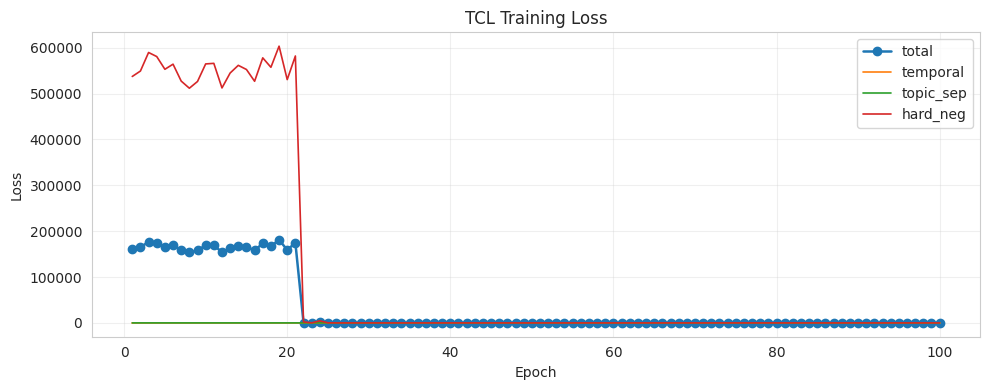

Saved best model: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_best.pt
Saved last model: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_last.pt
Saved train loss plot: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_train_loss.png


In [7]:
def build_scheduler(optimizer, config):
    # AP4-style cosine schedule after warmup.
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, int(config["epochs"]) - int(config["warmup_epochs"])),
        eta_min=float(config["min_lr"]),
    )


def plot_training_loss(history, save_path):
    if not history.get("epoch") or not history.get("loss"):
        return

    plt.figure(figsize=(10, 4))
    plt.plot(history["epoch"], history["loss"], marker="o", linewidth=1.8, label="total")
    if history.get("temporal_loss"):
        plt.plot(history["epoch"], history["temporal_loss"], linewidth=1.2, label="temporal")
    if history.get("topic_sep_loss"):
        plt.plot(history["epoch"], history["topic_sep_loss"], linewidth=1.2, label="topic_sep")
    if history.get("hard_neg_loss"):
        plt.plot(history["epoch"], history["hard_neg_loss"], linewidth=1.2, label="hard_neg")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("TCL Training Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


def train_tcl_model(model, train_loader, optimizer, loss_fn, config, device):
    scheduler = build_scheduler(optimizer, config)
    use_amp = bool(config["use_amp"] and torch.cuda.is_available())
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    history = {
        "epoch": [],
        "loss": [],
        "temporal_loss": [],
        "topic_sep_loss": [],
        "hard_neg_loss": [],
        "lr": [],
        "best_loss": float("inf"),
        "best_epoch": 0,
    }

    if len(train_loader) == 0:
        raise ValueError(
            "Train loader has zero batches. Reduce batch_size or increase available windows."
        )

    for epoch in range(int(config["epochs"])):
        model.train()
        batch_losses = []
        batch_temporal = []
        batch_topic_sep = []
        batch_hard_neg = []

        # AP4 warmup behavior.
        if epoch < int(config["warmup_epochs"]):
            warmup_lr = float(config["learning_rate"]) * float(epoch + 1) / float(config["warmup_epochs"])
            for param_group in optimizer.param_groups:
                param_group["lr"] = warmup_lr

        for windows, topic_ids in train_loader:
            windows = windows.to(device)
            topic_ids = topic_ids.to(device)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast():
                    embeddings = model(windows)
                    loss, loss_dict = loss_fn(embeddings, topic_ids)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
                scaler.step(optimizer)
                scaler.update()
            else:
                embeddings = model(windows)
                loss, loss_dict = loss_fn(embeddings, topic_ids)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
                optimizer.step()

            batch_losses.append(float(loss.item()))
            batch_temporal.append(float(loss_dict["temporal"]))
            batch_topic_sep.append(float(loss_dict["topic_separation"]))
            batch_hard_neg.append(float(loss_dict["hard_negative"]))

        if epoch >= int(config["warmup_epochs"]):
            scheduler.step()

        epoch_loss = float(np.mean(batch_losses))
        epoch_temporal = float(np.mean(batch_temporal))
        epoch_topic_sep = float(np.mean(batch_topic_sep))
        epoch_hard_neg = float(np.mean(batch_hard_neg))
        current_lr = float(optimizer.param_groups[0]["lr"])

        history["epoch"].append(epoch + 1)
        history["loss"].append(epoch_loss)
        history["temporal_loss"].append(epoch_temporal)
        history["topic_sep_loss"].append(epoch_topic_sep)
        history["hard_neg_loss"].append(epoch_hard_neg)
        history["lr"].append(current_lr)

        # Save best model by total loss.
        if epoch_loss < history["best_loss"]:
            history["best_loss"] = epoch_loss
            history["best_epoch"] = epoch + 1
            checkpoint = {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": epoch_loss,
                "loss_components": {
                    "temporal": epoch_temporal,
                    "topic_separation": epoch_topic_sep,
                    "hard_negative": epoch_hard_neg,
                },
                "config": config,
            }
            torch.save(checkpoint, config["model_best_path"])

        # AP4 periodic checkpointing.
        if bool(config.get("save_checkpoints", True)) and ((epoch + 1) % int(config.get("checkpoint_freq", 5)) == 0):
            checkpoint_path = os.path.join(config["output_path"], f"checkpoint_epoch_{epoch + 1}.pt")
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "loss": epoch_loss,
                    "loss_components": {
                        "temporal": epoch_temporal,
                        "topic_separation": epoch_topic_sep,
                        "hard_negative": epoch_hard_neg,
                    },
                    "config": config,
                },
                checkpoint_path,
            )

        print(
            f"Epoch {epoch + 1:03d} | total={epoch_loss:.5f} | "
            f"temporal={epoch_temporal:.5f} | topic_sep={epoch_topic_sep:.5f} | "
            f"hard_neg={epoch_hard_neg:.5f} | lr={current_lr:.2e}"
        )

    last_checkpoint = {
        "epoch": history["epoch"][-1] if history["epoch"] else 0,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": history["loss"][-1] if history["loss"] else None,
        "loss_components": {
            "temporal": history["temporal_loss"][-1] if history["temporal_loss"] else None,
            "topic_separation": history["topic_sep_loss"][-1] if history["topic_sep_loss"] else None,
            "hard_negative": history["hard_neg_loss"][-1] if history["hard_neg_loss"] else None,
        },
        "config": config,
    }
    torch.save(last_checkpoint, config["model_last_path"])

    plot_training_loss(history, config["train_loss_plot_path"])
    print(f"Saved best model: {config['model_best_path']}")
    print(f"Saved last model: {config['model_last_path']}")
    print(f"Saved train loss plot: {config['train_loss_plot_path']}")

    return model, history


model, training_history = train_tcl_model(model, train_loader, optimizer, loss_fn, config, device)

## 8. Evaluation

This cell computes embedding quality diagnostics: intra-topic similarity, inter-topic similarity, and separation score.

Purpose: verify representation quality before inference.

Evaluation Metrics:
{
  "intra_scores": {
    "War": 0.9999576633300015,
    "Health": 0.9999549525384684,
    "Economics": 0.9999477416276932,
    "Technology": 0.999939984236008,
    "Climate": 0.9999542881589417
  },
  "inter_scores": {
    "War-Health": -0.0716681307554245,
    "War-Economics": -0.07370056893676519,
    "War-Technology": -0.07169203951954842,
    "War-Climate": -0.07137929484248161,
    "Health-Economics": -0.07341056242585182,
    "Health-Technology": -0.07471060503274202,
    "Health-Climate": -0.07264717102050781,
    "Economics-Technology": -0.0726115433499217,
    "Economics-Climate": -0.07256102547049523,
    "Technology-Climate": -0.07094690158963203
  },
  "separation_score": -13.786194388766033,
  "similarity_extremes": {
    "intra_min": 0.9998189806938171,
    "intra_max": 0.999992311000824,
    "inter_min": -0.08335918933153152,
    "inter_max": -0.06694741547107697
  }
}

Similarity Extremes:
Intra -> min: 0.9998189806938171 | max: 0.999992311000824 | 

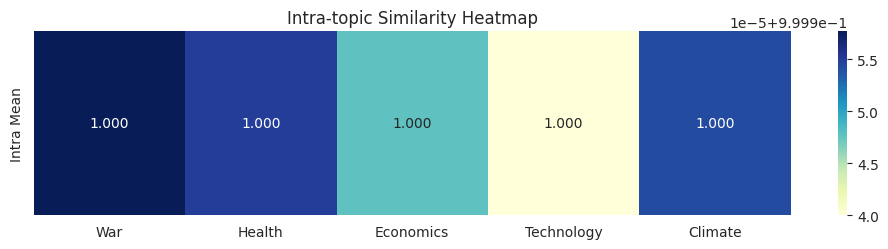

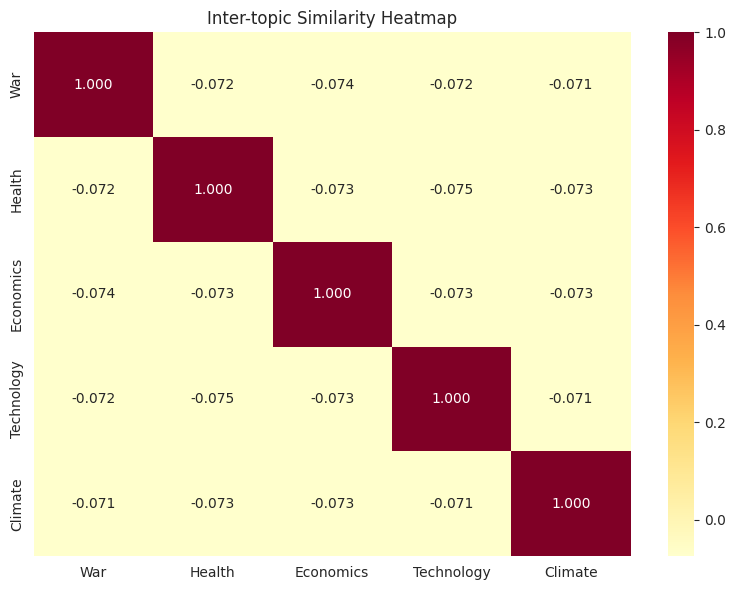

Saved evaluation metrics: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_evaluation_metrics.json
Saved intra heatmap: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_intra_heatmap.png
Saved inter heatmap: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_inter_heatmap.png
Saved evaluated model: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_evaluated.pt


In [8]:
def evaluate_model_quality(model, topic_window_data, config, device, per_topic_limit=200, inter_pairs=200, seed=42):
    model.eval()
    rng = np.random.default_rng(seed)
    topic_embeddings = {topic_name: [] for topic_name in config["topics"]}

    with torch.no_grad():
        for topic_name in config["topics"]:
            windows = topic_window_data[topic_name][:per_topic_limit]
            for window in windows:
                tensor = torch.from_numpy(window["tensor"]).unsqueeze(0).to(device)
                encoded = model(tensor).cpu().numpy()[0].astype(np.float32)
                topic_embeddings[topic_name].append(encoded)
            topic_embeddings[topic_name] = np.asarray(topic_embeddings[topic_name], dtype=np.float32)

    intra_scores = {}
    intra_pair_sims = {}
    for topic_name, embeddings in topic_embeddings.items():
        if len(embeddings) < 2:
            continue
        sims = []
        for i in range(len(embeddings) - 1):
            sims.append(float(np.dot(embeddings[i], embeddings[i + 1])))
        intra_pair_sims[topic_name] = sims
        intra_scores[topic_name] = float(np.mean(sims)) if sims else 0.0

    inter_scores = {}
    inter_pair_sims = {}
    topic_names = list(topic_embeddings.keys())
    for i in range(len(topic_names)):
        for j in range(i + 1, len(topic_names)):
            left_name, right_name = topic_names[i], topic_names[j]
            left = topic_embeddings[left_name]
            right = topic_embeddings[right_name]
            if len(left) == 0 or len(right) == 0:
                continue

            pairs = min(inter_pairs, len(left) * len(right))
            left_idx = rng.integers(0, len(left), size=pairs)
            right_idx = rng.integers(0, len(right), size=pairs)
            sims = [float(np.dot(left[li], right[ri])) for li, ri in zip(left_idx, right_idx)]

            pair_key = f"{left_name}-{right_name}"
            inter_pair_sims[pair_key] = sims
            inter_scores[pair_key] = float(np.mean(sims)) if sims else 0.0

    mean_intra = float(np.mean(list(intra_scores.values()))) if intra_scores else 0.0
    mean_inter = float(np.mean(list(inter_scores.values()))) if inter_scores else 0.0
    separation_score = mean_intra / (mean_inter + 1e-8) if mean_inter != 0 else 0.0

    intra_all = [v for values in intra_pair_sims.values() for v in values]
    inter_all = [v for values in inter_pair_sims.values() for v in values]

    similarity_extremes = {
        "intra_min": float(np.min(intra_all)) if intra_all else None,
        "intra_max": float(np.max(intra_all)) if intra_all else None,
        "inter_min": float(np.min(inter_all)) if inter_all else None,
        "inter_max": float(np.max(inter_all)) if inter_all else None,
    }

    return {
        "intra_scores": intra_scores,
        "inter_scores": inter_scores,
        "separation_score": separation_score,
        "similarity_extremes": similarity_extremes,
    }


def plot_evaluation_heatmaps(evaluation_metrics, config):
    topics = config["topics"]
    intra_scores = evaluation_metrics.get("intra_scores", {})
    inter_scores = evaluation_metrics.get("inter_scores", {})

    intra_values = [float(intra_scores.get(topic, np.nan)) for topic in topics]
    intra_matrix = np.asarray(intra_values, dtype=np.float32).reshape(1, -1)

    inter_matrix = np.full((len(topics), len(topics)), np.nan, dtype=np.float32)
    for i, left in enumerate(topics):
        inter_matrix[i, i] = 1.0
        for j, right in enumerate(topics):
            if i >= j:
                continue
            key = f"{left}-{right}"
            if key not in inter_scores:
                key = f"{right}-{left}"
            if key in inter_scores:
                inter_matrix[i, j] = float(inter_scores[key])
                inter_matrix[j, i] = float(inter_scores[key])

    plt.figure(figsize=(10, 2.6))
    sns.heatmap(
        intra_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        xticklabels=topics,
        yticklabels=["Intra Mean"],
        cbar=True,
    )
    plt.title("Intra-topic Similarity Heatmap")
    plt.tight_layout()
    plt.savefig(config["eval_heatmap_intra_path"], dpi=150)
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        inter_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        xticklabels=topics,
        yticklabels=topics,
        cbar=True,
    )
    plt.title("Inter-topic Similarity Heatmap")
    plt.tight_layout()
    plt.savefig(config["eval_heatmap_inter_path"], dpi=150)
    plt.show()


evaluation_metrics = evaluate_model_quality(model, topic_window_data, config, device)
print("Evaluation Metrics:")
print(json.dumps(evaluation_metrics, indent=2))

extremes = evaluation_metrics.get("similarity_extremes", {})
print("\nSimilarity Extremes:")
print(
    f"Intra -> min: {extremes.get('intra_min')} | max: {extremes.get('intra_max')} | "
    f"Inter -> min: {extremes.get('inter_min')} | max: {extremes.get('inter_max')}"
 )

plot_evaluation_heatmaps(evaluation_metrics, config)

with open(config["eval_metrics_path"], "w", encoding="utf-8") as file:
    json.dump(evaluation_metrics, file, indent=2)

evaluated_checkpoint = {
    "model_state_dict": model.state_dict(),
    "evaluation_metrics": evaluation_metrics,
    "config": config,
}
torch.save(evaluated_checkpoint, config["model_evaluated_path"])

print(f"Saved evaluation metrics: {config['eval_metrics_path']}")
print(f"Saved intra heatmap: {config['eval_heatmap_intra_path']}")
print(f"Saved inter heatmap: {config['eval_heatmap_inter_path']}")
print(f"Saved evaluated model: {config['model_evaluated_path']}")

## 9. Hugging Face Save and Push

Placement: run this section after model evaluation and before user inference.

This block saves run artifacts and uploads model checkpoints, config, metrics, and topic embeddings to Hugging Face for inference reuse.

In [9]:
# Optional inline auth setup (use this instead of .env loading):
os.environ.setdefault("HF_REPO_ID", "meet5568/tcl-approach")
os.environ.setdefault("HF_TOKEN_READ", "")
os.environ.setdefault("HF_TOKEN_PUSH", "")

# Hardcoded subfolder for Approach 4. Do not derive this from config or env.
HF_SUBFOLDER_FIXED = "approach_4"

# Example manual setup (uncomment and set real values when needed):
# os.environ["HF_REPO_ID"] = "your_username/your_repo"
# os.environ["HF_TOKEN_READ"] = "your_huggingface_read_token"
# os.environ["HF_TOKEN_PUSH"] = "your_huggingface_push_token"

def save_training_artifacts(config, training_history, evaluation_metrics):
    payload = {
        "config": config,
        "training_history": training_history,
        "evaluation_metrics": evaluation_metrics,
        "artifacts": {
            "model_best_path": config.get("model_best_path"),
            "model_last_path": config.get("model_last_path"),
            "model_evaluated_path": config.get("model_evaluated_path"),
            "train_loss_plot_path": config.get("train_loss_plot_path"),
            "eval_heatmap_intra_path": config.get("eval_heatmap_intra_path"),
            "eval_heatmap_inter_path": config.get("eval_heatmap_inter_path"),
            "eval_metrics_path": config.get("eval_metrics_path"),
        },
    }
    default_name = f"run_summary_new_{config.get('approach_id', '4')}.json"
    save_path = config.get("run_summary_path", os.path.join(config["output_path"], default_name))
    with open(save_path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, default=str)
    return save_path


def _build_hf_repo_id(cfg):
    repo_id = str(os.getenv("HF_REPO_ID") or cfg.get("hf_repo_id", "")).strip()
    if repo_id:
        return repo_id
    raise ValueError(
        "Missing HF_REPO_ID. Set it in this cell, e.g. os.environ['HF_REPO_ID'] = 'your_username/your_repo'."
    )


def _resolve_hf_token(mode, required=False):
    """
    mode='read'  -> HF_TOKEN_READ
    mode='push'  -> HF_TOKEN_PUSH
    """
    env_key = "HF_TOKEN_READ" if mode == "read" else "HF_TOKEN_PUSH"
    token = str(os.getenv(env_key) or "").strip()
    if required and not token:
        raise ValueError(
            f"Missing {env_key}. Set it in this cell, e.g. os.environ['{env_key}'] = 'your_huggingface_token'."
        )
    return token or None


def _build_hf_filenames(cfg):
    base_name = cfg["model_base_name"]
    base_hf_name = f"base_approch_{cfg.get('approach_id', '4')}"
    return {
        "best": f"{base_hf_name}_best.pt",
        "last": f"{base_hf_name}_last.pt",
        "evaluated": f"{base_hf_name}_evaluated.pt",
        "run_summary": f"{base_name}_run_summary.json",
        "evaluation_metrics": f"{base_name}_evaluation_metrics.json",
        "config": f"{base_hf_name}_config.json",
        "topic_embeddings": "topic_embeddings.json",
    }


def _upload_if_exists(api, repo_id, local_path, remote_path, commit_message):
    if not local_path or not os.path.exists(local_path):
        print(f"Skip upload (missing): {local_path}")
        return
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=remote_path,
        repo_id=repo_id,
        commit_message=commit_message,
    )
    print(f"Uploaded: {remote_path}")


def push_artifacts_to_huggingface(config, topic_embeddings_json_path=None):
    try:
        from huggingface_hub import HfApi, create_repo
    except ImportError as exc:
        raise ImportError(
            "huggingface_hub is required. Install it with: pip install huggingface_hub"
        ) from exc

    repo_id = _build_hf_repo_id(config)
    token = _resolve_hf_token(mode="push", required=True)
    subfolder = HF_SUBFOLDER_FIXED
    revision = str(config.get("hf_revision", "main"))
    filenames = _build_hf_filenames(config)
    config_to_upload = dict(config)
    print(f"Preparing full config upload with {len(config_to_upload)} keys")

    api = HfApi(token=token)
    create_repo(
        repo_id=repo_id,
        token=token,
        private=bool(config.get("hf_private_repo", False)),
        exist_ok=True,
    )

    export_config_path = os.path.join(config["output_path"], filenames["config"])

    with open(export_config_path, "w", encoding="utf-8") as file:
        json.dump(config_to_upload, file, indent=2, default=str)

    topic_path = topic_embeddings_json_path or config.get("topic_embeddings_source_path")
    commit_message = f"Upload artifacts for {config['model_base_name']}"

    upload_plan = [
        (config.get("model_best_path"), filenames["best"]),
        (config.get("model_last_path"), filenames["last"]),
        (config.get("model_evaluated_path"), filenames["evaluated"]),
        (config.get("run_summary_path"), filenames["run_summary"]),
        (config.get("eval_metrics_path"), filenames["evaluation_metrics"]),
        (export_config_path, filenames["config"]),
        (topic_path, filenames["topic_embeddings"]),
    ]

    for local_path, remote_name in upload_plan:
        remote_path = f"{subfolder}/{remote_name}" if subfolder else remote_name
        _upload_if_exists(
            api=api,
            repo_id=repo_id,
            local_path=local_path,
            remote_path=remote_path,
            commit_message=commit_message,
        )

    return {
        "repo_id": repo_id,
        "revision": revision,
        "subfolder": subfolder,
        "filenames": filenames,
    }


def download_hf_inference_artifacts(config, load_variant=None):
    try:
        from huggingface_hub import hf_hub_download
    except ImportError as exc:
        raise ImportError(
            "huggingface_hub is required. Install it with: pip install huggingface_hub"
        ) from exc

    repo_id = _build_hf_repo_id(config)
    token = _resolve_hf_token(mode="read", required=True)
    revision = str(config.get("hf_revision", "main"))
    subfolder = HF_SUBFOLDER_FIXED
    variant = str(load_variant or config.get("load_variant", "best")).lower().strip()
    filenames = _build_hf_filenames(config)

    if variant not in {"best", "last", "evaluated"}:
        raise ValueError("load_variant must be one of: best, last, evaluated")

    checkpoint_name = f"{subfolder}/{filenames[variant]}" if subfolder else filenames[variant]
    config_name = f"{subfolder}/{filenames['config']}" if subfolder else filenames['config']
    topic_name = f"{subfolder}/{filenames['topic_embeddings']}" if subfolder else filenames['topic_embeddings']

    checkpoint_path = hf_hub_download(
        repo_id=repo_id,
        filename=checkpoint_name,
        revision=revision,
        token=token,
    )
    config_path = hf_hub_download(
        repo_id=repo_id,
        filename=config_name,
        revision=revision,
        token=token,
    )
    topic_embeddings_path = hf_hub_download(
        repo_id=repo_id,
        filename=topic_name,
        revision=revision,
        token=token,
    )

    with open(config_path, "r", encoding="utf-8") as file:
        remote_config = json.load(file)

    return {
        "repo_id": repo_id,
        "revision": revision,
        "subfolder": subfolder,
        "checkpoint_path": checkpoint_path,
        "config_path": config_path,
        "topic_embeddings_path": topic_embeddings_path,
        "remote_config": remote_config,
    }


summary_path = save_training_artifacts(config, training_history, evaluation_metrics)
print(f"Saved summary: {summary_path}")

# Upload training artifacts to Hugging Face so inference can load from Hub.
hf_push_info = push_artifacts_to_huggingface(config)
print(
    f"Uploaded artifacts to Hugging Face: {hf_push_info['repo_id']}"
    f"/{hf_push_info['subfolder']}"
)

Saved summary: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_run_summary.json
Preparing full config upload with 77 keys


Processing Files (1 / 1): 100%|██████████|  161MB /  161MB, 49.7MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


Uploaded: approach_4/base_approch_4_best.pt


Processing Files (1 / 1): 100%|██████████|  161MB /  161MB, 75.8MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


Uploaded: approach_4/base_approch_4_last.pt


Processing Files (1 / 1): 100%|██████████| 53.8MB / 53.8MB, 17.2MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


Uploaded: approach_4/base_approch_4_evaluated.pt
Uploaded: approach_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_run_summary.json
Uploaded: approach_4/approch_ruptures_pen0p1_4_w4_s1_t0p05_evaluation_metrics.json
Uploaded: approach_4/base_approch_4_config.json
Skip upload (missing): None
Uploaded artifacts to Hugging Face: meet5568/tcl-approach/approach_4


## 9. Inference (User-level)

This section transforms raw user input (`date`, `article`) into training-like sentence rows, applies topic filtering, then reuses the same temporal pipeline used in training.

Result: shift timeline with top contributing sentences.

### Inference Design Notes

- **Context window**: each sentence embedding is generated from contextual text, not isolated text. With `context_window=3`, we use `prev + current + next`; with `context_window=5`, we use `prev2 + prev1 + current + next1 + next2`. This improves semantic quality and reduces noisy single-sentence variance.
- **Soft topic labeling**: every sentence is compared with each topic prototype using cosine similarity. This gives a continuous topic-contribution score instead of hard class labels.
- **Threshold filtering**: only rows where `topic == user_topic` and `similarity_score >= config['topic_threshold']` pass to temporal modeling. This keeps topic-relevant content for stable drift signals.
- **Training-inference alignment**: after filtering, inference uses the same steps as training: daily mean pooling, temporal feature append, sliding windows, encoder forward pass, and consecutive-window drift computation.

In [13]:
def compute_topic_drift(model, topic_windows, config, device):
    model.eval()
    window_embeddings = []

    with torch.no_grad():
        for window in topic_windows:
            tensor = torch.from_numpy(window["tensor"]).unsqueeze(0).to(device)
            encoded = model(tensor).cpu().numpy()[0].astype(np.float32)
            window_embeddings.append(encoded)

    window_embeddings = np.asarray(window_embeddings, dtype=np.float32)
    if len(window_embeddings) < 2:
        return [], window_embeddings

    # AP4 core scoring: raw drift = 1 - cosine_similarity(consecutive windows)
    shift_scores_raw = []
    for i in range(len(window_embeddings) - 1):
        sim = float(np.dot(window_embeddings[i], window_embeddings[i + 1]))
        shift_scores_raw.append(np.float32(1.0 - sim))

    shift_scores_raw = np.asarray(shift_scores_raw, dtype=np.float32)

    # AP4 inference path normalizes raw drifts to [0, 1], then applies manual threshold.
    score_min = float(np.min(shift_scores_raw))
    score_max = float(np.max(shift_scores_raw))
    if (score_max - score_min) > 1e-8:
        shift_scores = ((shift_scores_raw - score_min) / (score_max - score_min)).astype(np.float32)
    else:
        shift_scores = np.zeros_like(shift_scores_raw, dtype=np.float32)

    threshold = float(config.get("manual_shift_threshold", 0.1))

    # Keep z-score for ranking diagnostics.
    mean_score = np.float32(np.mean(shift_scores))
    std_score = np.float32(np.std(shift_scores)) + np.float32(1e-8)
    z_scores = ((shift_scores - mean_score) / std_score).astype(np.float32)

    drift_rows = []
    for i, (raw_score, score, z_score) in enumerate(zip(shift_scores_raw, shift_scores, z_scores)):
        drift_rows.append({
            "window_idx": int(i),
            "date": topic_windows[i + 1]["start_date"],
            "raw_drift": float(raw_score),
            "drift_score": float(score),
            "z_score": float(z_score),
            "threshold": float(threshold)
        })

    return drift_rows, window_embeddings


def detect_shifts(drift_rows, config):
    if not drift_rows:
        return []

    threshold = float(drift_rows[0].get("threshold", 0.0))
    shifts = []
    for row in drift_rows:
        if float(row.get("drift_score", 0.0)) > threshold:
            shifts.append(row)
    return shifts


def split_articles_into_sentences(input_dataframe):
    import re

    sentence_rows = []
    required_cols = {"date", "article"}
    missing = required_cols - set(input_dataframe.columns)
    if missing:
        raise ValueError(f"Input CSV must contain columns: {required_cols}. Missing: {missing}")

    for article_idx, row in input_dataframe.reset_index(drop=True).iterrows():
        article_id = row.get("article_id", f"article_{article_idx}")
        date_value = pd.to_datetime(row["date"], errors="coerce")
        if pd.isna(date_value):
            continue

        text = str(row["article"]).strip()
        if not text:
            continue

        sentence_list = [
            s.strip()
            for s in re.split(r"(?<=[.!?])\s+", text)
            if s and s.strip()
        ]

        for sentence_order, sentence_text in enumerate(sentence_list):
            sentence_id = f"{article_id}_s{sentence_order}"
            sentence_rows.append({
                "date": date_value,
                "article_id": str(article_id),
                "sentence_id": sentence_id,
                "sentence_text": sentence_text,
                "sentence_order": int(sentence_order)
            })

    sentence_dataframe = pd.DataFrame(sentence_rows)
    if sentence_dataframe.empty:
        return pd.DataFrame(columns=["date", "article_id", "sentence_id", "sentence_text", "sentence_order"])
    return sentence_dataframe[["date", "article_id", "sentence_id", "sentence_text", "sentence_order"]]

## 10. Utilities (if needed)

This cell contains helper routines for saving run artifacts (config, training history, evaluation metrics) to JSON.

In [14]:
def save_training_artifacts(config, training_history, evaluation_metrics):
    payload = {
        "config": config,
        "training_history": training_history,
        "evaluation_metrics": evaluation_metrics,
        "artifacts": {
            "model_best_path": config.get("model_best_path"),
            "model_last_path": config.get("model_last_path"),
            "model_evaluated_path": config.get("model_evaluated_path"),
            "train_loss_plot_path": config.get("train_loss_plot_path"),
            "eval_heatmap_intra_path": config.get("eval_heatmap_intra_path"),
            "eval_heatmap_inter_path": config.get("eval_heatmap_inter_path"),
            "eval_metrics_path": config.get("eval_metrics_path"),
        },
    }
    save_path = config.get("run_summary_path", os.path.join(config["output_path"], "run_summary_new_1.json"))
    with open(save_path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, default=str)
    return save_path


summary_path = save_training_artifacts(config, training_history, evaluation_metrics)
print(f"Saved summary: {summary_path}")

Saved summary: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w2_s1_t0p05_run_summary.json


## 11. User Inference Call

Run this cell to execute user-level inference on a CSV file and preview shift outputs.

In [15]:
# CPU-safe override for inference embedding generation
# This redefines the earlier function so SentenceTransformer runs on CPU.
def generate_contextual_sbert_embeddings(sentence_dataframe, config, sbert_model_name="all-mpnet-base-v2"):
    from sentence_transformers import SentenceTransformer

    if sentence_dataframe.empty:
        sentence_dataframe["sentence_embeddings"] = []
        return sentence_dataframe

    if int(config["embedding_dim"]) != 768:
        raise ValueError("Inference requires config['embedding_dim'] == 768 to match trained Approach-4 pipeline")

    model_sbert = SentenceTransformer(sbert_model_name, device="cpu")
    encoded = model_sbert.encode(
        sentence_dataframe["context_text"].tolist(),
        batch_size=int(config["inference_batch_size"]),
        show_progress_bar=False,
        convert_to_numpy=True
    )
    encoded = np.asarray(encoded, dtype=np.float32)

    if encoded.shape[1] != config["embedding_dim"]:
        raise ValueError(
            f"SBERT output dim {encoded.shape[1]} does not match config['embedding_dim']={config['embedding_dim']}"
        )

    sentence_dataframe = sentence_dataframe.copy()
    sentence_dataframe["sentence_embeddings"] = [vec.astype(np.float32) for vec in encoded]
    return sentence_dataframe

In [16]:
def build_context_texts(sentence_dataframe, context_window):
    if context_window not in (3, 5):
        raise ValueError("context_window must be 3 or 5")

    radius = context_window // 2
    sentence_dataframe = sentence_dataframe.sort_values(["article_id", "sentence_order"]).reset_index(drop=True).copy()
    context_texts = [""] * len(sentence_dataframe)

    for _, group in sentence_dataframe.groupby("article_id", sort=False):
        indices = group.index.tolist()
        sentences = group["sentence_text"].tolist()

        for local_idx, global_idx in enumerate(indices):
            left = max(0, local_idx - radius)
            right = min(len(sentences), local_idx + radius + 1)
            context_texts[global_idx] = " ".join(sentences[left:right])

    sentence_dataframe["context_text"] = context_texts
    return sentence_dataframe


def load_topic_embedding_prototypes(topic_embeddings_json_path, config):
    with open(topic_embeddings_json_path, "r", encoding="utf-8") as file:
        payload = json.load(file)

    topic_embeddings = {}
    for topic_name in config["topics"]:
        if topic_name not in payload:
            raise KeyError(f"Topic '{topic_name}' missing in {topic_embeddings_json_path}")
        vector = np.asarray(payload[topic_name], dtype=np.float32)
        if vector.shape[0] != config["embedding_dim"]:
            raise ValueError(
                f"Topic embedding dim mismatch for {topic_name}: {vector.shape[0]} vs {config['embedding_dim']}"
            )
        norm = np.linalg.norm(vector)
        topic_embeddings[topic_name] = (vector / (norm + 1e-8)).astype(np.float32)

    return topic_embeddings


def soft_topic_label_sentences(sentence_dataframe, topic_embeddings, config):
    rows = []
    topic_names = config["topics"]
    topic_matrix = np.stack([topic_embeddings[name] for name in topic_names]).astype(np.float32)
    topic_table_64 = np.asarray(config["topic_embedding_table"], dtype=np.float32)
    expected_shape = (len(topic_names), int(config["topic_embedding_dim"]))
    if topic_table_64.shape != expected_shape:
        raise ValueError(
            f"topic_embedding_table shape mismatch: {topic_table_64.shape} vs {expected_shape}"
        )

    if sentence_dataframe.empty:
        base_cols = [
            "date",
            "article_id",
            "sentence_id",
            "sentence_text",
            "sentence_order",
            "sentence_embeddings",
            "topic_embeddings",
            "topic_probabilities",
        ] + topic_names
        return pd.DataFrame(columns=base_cols)

    for row in sentence_dataframe.itertuples(index=False):
        emb = np.asarray(row.sentence_embeddings, dtype=np.float32)
        emb = emb / (np.linalg.norm(emb) + 1e-8)

        similarities = np.dot(topic_matrix, emb).astype(np.float32)
        exp_sim = np.exp(similarities - np.max(similarities)).astype(np.float32)
        topic_probs = (exp_sim / (exp_sim.sum() + 1e-8)).astype(np.float32)

        topic_vec_64 = np.dot(topic_probs, topic_table_64).astype(np.float32)
        topic_vec_64 = topic_vec_64 / (np.linalg.norm(topic_vec_64) + 1e-8)

        record = {
            "date": row.date,
            "article_id": row.article_id,
            "sentence_id": row.sentence_id,
            "sentence_text": row.sentence_text,
            "sentence_order": int(row.sentence_order),
            "sentence_embeddings": emb.astype(np.float32),
            "topic_embeddings": topic_vec_64.astype(np.float32),
            "w3_embedding": emb.astype(np.float32),
            "w5_embedding": emb.astype(np.float32),
            "topic_probabilities": topic_probs.astype(np.float32),
        }

        for topic_idx, topic_name in enumerate(topic_names):
            record[topic_name] = np.float32(topic_probs[topic_idx])

        rows.append(record)

    return pd.DataFrame(rows)


def build_topic_score_rows(labeled_sentence_dataframe, config):
    rows = []
    for row in labeled_sentence_dataframe.itertuples(index=False):
        for topic_name in config["topics"]:
            rows.append(
                {
                    "sentence_id": row.sentence_id,
                    "topic": topic_name,
                    "similarity_score": float(getattr(row, topic_name)),
                }
            )
    return rows


def filter_user_topic_sentences(labeled_sentence_dataframe, user_topic, config):
    if user_topic not in config["topics"]:
        raise ValueError(f"Unknown topic '{user_topic}'. Expected one of {config['topics']}")

    filtered = labeled_sentence_dataframe[
        labeled_sentence_dataframe[user_topic] >= float(config["topic_threshold"])
    ].copy()
    filtered["selected_topic"] = user_topic
    filtered["similarity_score"] = filtered[user_topic].astype(np.float32)

    return filtered.sort_values(["date", "article_id", "sentence_order"]).reset_index(drop=True)


def _get_expected_topic_prob_dim(config):
    return int(config.get("topic_prob_dim", len(config.get("topics", []))))


def _get_expected_topic_emb_dim(config):
    return int(config.get("topic_dim", config.get("topic_embedding_dim", 0)))


def validate_inference_alignment(config, filtered_sentence_dataframe):
    required_cols = {"date", "sentence_embeddings", "topic_embeddings", "topic_probabilities", "sentence_text", "sentence_id"}
    missing = required_cols - set(filtered_sentence_dataframe.columns)
    if missing:
        raise ValueError(f"Filtered inference data missing required columns: {missing}")

    emb_dim_ok = filtered_sentence_dataframe["sentence_embeddings"].apply(
        lambda x: len(x) == int(config["embedding_dim"])
    ).all()

    expected_topic_emb_dim = _get_expected_topic_emb_dim(config)
    topic_emb_dim_ok = filtered_sentence_dataframe["topic_embeddings"].apply(
        lambda x: len(x) == expected_topic_emb_dim
    ).all()

    expected_topic_prob_dim = _get_expected_topic_prob_dim(config)
    topic_prob_dim_ok = filtered_sentence_dataframe["topic_probabilities"].apply(
        lambda x: len(x) == expected_topic_prob_dim
    ).all()

    if not emb_dim_ok:
        raise ValueError("Inference sentence embedding dimension mismatch detected")
    if not topic_emb_dim_ok:
        raise ValueError(
            f"Inference topic embedding dimension mismatch detected: expected {expected_topic_emb_dim}"
        )
    if not topic_prob_dim_ok:
        raise ValueError(
            f"Inference topic probability dimension mismatch detected: expected {expected_topic_prob_dim}"
        )

    return True




In [17]:
def get_user_inference_call_order():
    return [
        "1. split_articles_into_sentences",
        "2. build_context_texts",
        "3. generate_contextual_sbert_embeddings",
        "4. compute topic weights using ideal 768-d embeddings",
        "5. filter by topic threshold",
        "6. daily weighted pooling + add 64-d TCL topic embedding",
        "7. build temporal windows (adaptive if days < window_size)",
        "8. compute_topic_drift + detect_shifts",
        "9. sentence-level shift detection with context",
    ]


def _normalize_topic_label(text):
    text = str(text).strip().lower()
    return "".join(ch for ch in text if ch.isalnum())


def resolve_topic_name(user_topic, config_topics):
    if user_topic in config_topics:
        return user_topic

    target = _normalize_topic_label(user_topic)
    scored = []
    for topic in config_topics:
        norm_topic = _normalize_topic_label(topic)
        if not norm_topic:
            continue
        if target == norm_topic:
            return topic
        if target in norm_topic or norm_topic in target:
            scored.append((len(norm_topic), topic))

    if scored:
        scored.sort(reverse=True)
        return scored[0][1]

    raise ValueError(f"Unsupported topic '{user_topic}'. Choose one of: {config_topics}")


def _to_int_article_id(article_id_value):
    text = str(article_id_value)
    digits = "".join(ch for ch in text if ch.isdigit())
    return int(digits) if digits else -1


def load_ideal_topic_embeddings_for_inference(topic_embeddings_json_path, config):
    topic_embeddings = load_topic_embedding_prototypes(topic_embeddings_json_path, config)
    for topic_name in config["topics"]:
        vec = np.asarray(topic_embeddings[topic_name], dtype=np.float32)
        if vec.shape[0] != int(config["embedding_dim"]):
            raise ValueError(
                f"Ideal topic embedding dim mismatch for {topic_name}: {vec.shape[0]} vs {config['embedding_dim']}"
            )
    return topic_embeddings


def load_tcl_topic_embeddings_for_inference(tcl_topic_embeddings_json_path, config):
    expected_dim = int(config["topic_embedding_dim"])

    if tcl_topic_embeddings_json_path and os.path.exists(tcl_topic_embeddings_json_path):
        with open(tcl_topic_embeddings_json_path, "r", encoding="utf-8") as file:
            payload = json.load(file)

        topic_embeddings = {}
        for topic_name in config["topics"]:
            if topic_name not in payload:
                raise KeyError(f"Topic '{topic_name}' missing in {tcl_topic_embeddings_json_path}")
            vector = np.asarray(payload[topic_name], dtype=np.float32)
            if vector.shape[0] != expected_dim:
                raise ValueError(
                    f"TCL topic embedding dim mismatch for {topic_name}: {vector.shape[0]} vs {expected_dim}"
                )
            topic_embeddings[topic_name] = vector
        return topic_embeddings

    # Fallback to notebook config table when a saved TCL embedding file is not provided.
    topic_table = np.asarray(config["topic_embedding_table"], dtype=np.float32)
    expected_shape = (len(config["topics"]), expected_dim)
    if topic_table.shape != expected_shape:
        raise ValueError(f"config['topic_embedding_table'] shape mismatch: {topic_table.shape} vs {expected_shape}")

    return {topic_name: topic_table[idx].copy() for idx, topic_name in enumerate(config["topics"])}


def compute_topic_similarity_with_embeddings(sentence_embeddings, topic_embedding):
    sentence_embeddings = np.asarray(sentence_embeddings, dtype=np.float32)
    topic_embedding = np.asarray(topic_embedding, dtype=np.float32)

    sentence_embeddings = sentence_embeddings / (np.linalg.norm(sentence_embeddings, axis=1, keepdims=True) + 1e-8)
    topic_embedding = topic_embedding / (np.linalg.norm(topic_embedding) + 1e-8)

    similarities = sentence_embeddings @ topic_embedding
    similarities = (similarities + 1.0) / 2.0
    similarities = np.maximum(similarities, 0.3).astype(np.float32)
    return similarities


def _build_sentence_context_string(row, source_df, context_window=2):
    article_rows = source_df[source_df["article_id"].astype(str) == str(row["article_id"])].copy()
    if article_rows.empty:
        return f">>> [{row['sentence_id']}] {row['sentence_text']}"

    article_rows = article_rows.sort_values("sentence_order").reset_index(drop=True)
    positions = article_rows.index[article_rows["sentence_id"].astype(str) == str(row["sentence_id"])].tolist()
    if not positions:
        return f">>> [{row['sentence_id']}] {row['sentence_text']}"

    pos = positions[0]
    start = max(0, pos - int(context_window))
    end = min(len(article_rows), pos + int(context_window) + 1)
    subset = article_rows.iloc[start:end]

    lines = []
    current_order = int(row["sentence_order"])
    for _, record in subset.iterrows():
        prefix = ">>> " if int(record["sentence_order"]) == current_order else "    "
        lines.append(f"{prefix}[{record['sentence_id']}] {record['sentence_text']}")
    return "\n".join(lines)


In [22]:
def extract_sentence_level_narrative_shifts(
    filtered_sentence_dataframe,
    drift_rows,
    config,
    top_k_shifts=5,
    per_date_sent_limit=40,
    context_window=2,
):
    if filtered_sentence_dataframe.empty or not drift_rows:
        return []

    detected_shifts = detect_shifts(drift_rows, config)
    if not detected_shifts:
        return []

    filtered = filtered_sentence_dataframe.copy()
    filtered["date"] = pd.to_datetime(filtered["date"]).dt.normalize()

    unique_dates = sorted(filtered["date"].unique())
    if len(unique_dates) < 2:
        return []

    sentence_level_shifts = []
    used_sentence_ids = set()
    used_sentence_pairs = set()
    ranked_shifts = sorted(detected_shifts, key=lambda x: x.get("z_score", 0.0), reverse=True)[: int(top_k_shifts)]

    for shift in ranked_shifts:
        date_2 = pd.Timestamp(shift["date"]).normalize()
        previous_dates = [date_value for date_value in unique_dates if date_value < date_2]
        if not previous_dates:
            continue

        date_1 = previous_dates[-1]

        sents_1 = (
            filtered[filtered["date"] == date_1]
            .sort_values("similarity_score", ascending=False)
            .head(int(per_date_sent_limit))
            .reset_index(drop=True)
        )
        sents_2 = (
            filtered[filtered["date"] == date_2]
            .sort_values("similarity_score", ascending=False)
            .head(int(per_date_sent_limit))
            .reset_index(drop=True)
        )

        if sents_1.empty or sents_2.empty:
            continue

        embs_1 = np.stack(sents_1["sentence_embeddings"].values).astype(np.float32)
        embs_2 = np.stack(sents_2["sentence_embeddings"].values).astype(np.float32)

        norm_1 = embs_1 / (np.linalg.norm(embs_1, axis=1, keepdims=True) + 1e-8)
        norm_2 = embs_2 / (np.linalg.norm(embs_2, axis=1, keepdims=True) + 1e-8)
        sims = np.dot(norm_1, norm_2.T).astype(np.float32)

        # Select the least-similar pair that does not reuse sentence_1/sentence_2.
        candidate_flat_indices = np.argsort(sims, axis=None)
        chosen = None
        for flat_idx in candidate_flat_indices:
            idx_1, idx_2 = np.unravel_index(int(flat_idx), sims.shape)
            cand_1 = sents_1.iloc[idx_1]
            cand_2 = sents_2.iloc[idx_2]

            sentence_id_1 = str(cand_1["sentence_id"])
            sentence_id_2 = str(cand_2["sentence_id"])
            pair_key = tuple(sorted((sentence_id_1, sentence_id_2)))

            if sentence_id_1 in used_sentence_ids or sentence_id_2 in used_sentence_ids:
                continue
            if pair_key in used_sentence_pairs:
                continue

            chosen = (idx_1, idx_2, sentence_id_1, sentence_id_2, pair_key)
            break

        if chosen is None:
            continue

        idx_1, idx_2, sentence_id_1, sentence_id_2, pair_key = chosen
        min_similarity = float(sims[idx_1, idx_2])

        sent1 = sents_1.iloc[idx_1]
        sent2 = sents_2.iloc[idx_2]

        sentence_level_shifts.append(
            {
                "date_1": str(pd.Timestamp(date_1).date()),
                "date_2": str(pd.Timestamp(date_2).date()),
                "sentence_id_1": sentence_id_1,
                "article_id_1": _to_int_article_id(sent1["article_id"]),
                "sentence_num_1": int(sent1["sentence_order"]),
                "sentence_1": str(sent1["sentence_text"]),
                "topic_weight_1": float(sent1["similarity_score"]),
                "sentence_id_2": sentence_id_2,
                "article_id_2": _to_int_article_id(sent2["article_id"]),
                "sentence_num_2": int(sent2["sentence_order"]),
                "sentence_2": str(sent2["sentence_text"]),
                "topic_weight_2": float(sent2["similarity_score"]),
                "context_1": _build_sentence_context_string(sent1, filtered, context_window=context_window),
                "context_2": _build_sentence_context_string(sent2, filtered, context_window=context_window),
                "similarity": min_similarity,
                "shift_score": float(1.0 - min_similarity),
                "day_level_shift_score": float(shift.get("drift_score", 0.0)),
                "day_level_z_score": float(shift.get("z_score", 0.0)),
            }
        )

        used_sentence_ids.add(sentence_id_1)
        used_sentence_ids.add(sentence_id_2)
        used_sentence_pairs.add(pair_key)

    return sentence_level_shifts


In [23]:
# AP4-aligned user inference: ideal 768-d topic weighting + TCL 64-d topic feature concat.
def run_user_level_inference(
    user_csv_path,
    model,
    config,
    topic_name,
    ideal_topic_embeddings_json_path=None,
    topic_embeddings_json_path=None,
    tcl_topic_embeddings_json_path=None,
    sbert_model_name="all-mpnet-base-v2"
):
    call_order = get_user_inference_call_order()
    resolved_topic = resolve_topic_name(topic_name, config["topics"])

    ideal_path = ideal_topic_embeddings_json_path or topic_embeddings_json_path
    if not ideal_path:
        raise ValueError("Provide ideal_topic_embeddings_json_path (or topic_embeddings_json_path for backward compatibility)")

    input_dataframe = pd.read_csv(user_csv_path)
    sentence_dataframe = split_articles_into_sentences(input_dataframe)
    if sentence_dataframe.empty:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": [],
            "topic_score_rows": [],
            "training_like_rows": []
        }

    sentence_dataframe = build_context_texts(sentence_dataframe, int(config["context_window"]))
    sentence_dataframe = generate_contextual_sbert_embeddings(
        sentence_dataframe, config, sbert_model_name=sbert_model_name
    )

    ideal_embeddings = load_ideal_topic_embeddings_for_inference(ideal_path, config)
    tcl_topic_embeddings = load_tcl_topic_embeddings_for_inference(tcl_topic_embeddings_json_path, config)

    # Reuse shared labeling helper instead of duplicating soft-label calculations here.
    labeled_sentence_dataframe = soft_topic_label_sentences(sentence_dataframe, ideal_embeddings, config)

    sentence_matrix = np.stack(labeled_sentence_dataframe["sentence_embeddings"].values).astype(np.float32)
    selected_topic_embedding = ideal_embeddings[resolved_topic]
    topic_weights = compute_topic_similarity_with_embeddings(sentence_matrix, selected_topic_embedding)

    labeled_sentence_dataframe = labeled_sentence_dataframe.copy()
    labeled_sentence_dataframe["similarity_score"] = topic_weights
    labeled_sentence_dataframe["selected_topic"] = resolved_topic

    topic_score_rows = build_topic_score_rows(labeled_sentence_dataframe, config)

    threshold = float(config.get("topic_threshold", config.get("topic_weight_threshold", 0.55)))
    filtered_sentence_dataframe = labeled_sentence_dataframe[
        labeled_sentence_dataframe["similarity_score"].astype(np.float32) >= threshold
    ].copy().sort_values(["date", "article_id", "sentence_order"]).reset_index(drop=True)

    if filtered_sentence_dataframe.empty:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": [],
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
        }

    # AP4 feature path: fixed topic-level 64-d vector for selected topic.
    topic_vec_64 = np.asarray(tcl_topic_embeddings[resolved_topic], dtype=np.float32)
    filtered_sentence_dataframe["topic_embeddings"] = [topic_vec_64.copy() for _ in range(len(filtered_sentence_dataframe))]

    validate_inference_alignment(config, filtered_sentence_dataframe)

    # AP4-style daily weighted pooling using topic relevance scores.
    daily_rows = []
    grouped = filtered_sentence_dataframe.groupby(pd.to_datetime(filtered_sentence_dataframe["date"]).dt.normalize())
    for date_value, group in grouped:
        embeddings = np.stack(group["sentence_embeddings"].values).astype(np.float32)
        raw_weights = np.clip(group["similarity_score"].astype(np.float32).values, a_min=0.0, a_max=None)
        if raw_weights.sum() > 0:
            weights = raw_weights / raw_weights.sum()
        else:
            weights = np.ones(len(group), dtype=np.float32) / max(len(group), 1)

        daily_embedding = (embeddings.T @ weights).astype(np.float32)
        daily_embedding = daily_embedding / (np.linalg.norm(daily_embedding) + 1e-8)

        daily_rows.append({
            "date": pd.Timestamp(date_value),
            "daily_vectors": daily_embedding,
            "topic_embeddings": topic_vec_64.copy(),
            "topic_name": resolved_topic,
            "topic_id": int(config["topics"].index(resolved_topic)),
            "num_sentences": int(len(group)),
        })

    user_daily_df = pd.DataFrame(daily_rows).sort_values("date").reset_index(drop=True)
    if user_daily_df.empty:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": [],
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
        }

    user_records = add_temporal_features(user_daily_df)

    # AP4-style adaptive windowing when available days are fewer than window_size.
    if len(user_records) < int(config["window_size"]):
        user_windows = []
        for idx, record in enumerate(user_records):
            padded_tensor = np.stack([record["final_vector"]] * int(config["window_size"])).astype(np.float32)
            user_windows.append({
                "tensor": padded_tensor,
                "topic_id": int(config["topics"].index(resolved_topic)),
                "topic_name": resolved_topic,
                "start_date": record["date"],
                "end_date": record.get("end_date", record["date"]),
                "window_idx": idx,
                "is_adaptive": True,
            })
    else:
        user_windows = build_window_embeddings(
            user_records,
            resolved_topic,
            int(config["topics"].index(resolved_topic)),
            config
        )
        for window in user_windows:
            window["is_adaptive"] = False

    if len(user_windows) < 2:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": filtered_sentence_dataframe
                .sort_values("similarity_score", ascending=False)
                .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
                .to_dict(orient="records"),
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
        }

    drift_rows, _ = compute_topic_drift(model, user_windows, config, device)

    sentence_level_shifts = extract_sentence_level_narrative_shifts(
        filtered_sentence_dataframe=filtered_sentence_dataframe,
        drift_rows=drift_rows,
        config=config,
        top_k_shifts=5,
        per_date_sent_limit=40,
        context_window=2
    )

    top_topic_sentences = (
        filtered_sentence_dataframe
        .sort_values("similarity_score", ascending=False)
        .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
        .to_dict(orient="records")
    )

    return {
        "call_order": call_order,
        "resolved_topic": resolved_topic,
        "sentence_level_narrative_shifts": sentence_level_shifts,
        "top_topic_sentences": top_topic_sentences,
        "topic_score_rows": topic_score_rows,
        "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
    }


In [ ]:
# Batch inference call (load stored model once, run on all CSV files, save TXT per file)
from pathlib import Path

# -----------------------------
# User-provided paths
# -----------------------------
input_directory = "/home/hp/SEM2/INLP/Naretve_Shift/Output/Model_Testing/Aprroch_4"
output_directory = "/home/hp/SEM2/INLP/Naretve_Shift/Output/Model_Testing/Aprroch_4/outputs"
ideal_topic_embeddings_json_path = "/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/topic_embeddings.json"

# Approach 4 testing: use config['topic_embedding_table'] fallback (no external TCL topic embedding file).
tcl_topic_embeddings_json_path = None

# Enter one or many topics here. Example: ["War", "Health"] or config["topics"] for all.
selected_topics = config["topics"]

# -----------------------------
# Inference interface settings
# -----------------------------
inference_config = dict(config)
inference_config["topic_threshold"] = 0.60
inference_config["manual_shift_threshold"] = config.get("manual_shift_threshold", 0.1)

# Select model variant to load from interface config: best | last | evaluated
inference_config["load_variant"] = "best"
inference_config.update(build_artifact_paths(inference_config))

# Ensure output folder exists
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Fallback order avoids forcing retrain when older checkpoints exist.
legacy_best_path = os.path.join(inference_config["output_path"], "tcl_model_best_new_2.pt")
candidate_paths = [
    inference_config["model_load_path"],
    inference_config.get("model_evaluated_path"),
    legacy_best_path,
]
checkpoint_path = next((p for p in candidate_paths if p and os.path.exists(p)), None)
if checkpoint_path is None:
    raise FileNotFoundError(
        "Checkpoint not found in candidates: " + ", ".join([str(p) for p in candidate_paths if p])
    )

# Force inference to run on CPU
inference_device = torch.device("cpu")
device = inference_device

# Load model once and reuse for all files
inference_model = TCLTemporalEncoder(config).to(inference_device)
checkpoint = load_checkpoint_compat(checkpoint_path, inference_device)
state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint

try:
    inference_model.load_state_dict(state_dict)
except RuntimeError as exc:
    raise RuntimeError(
        "Checkpoint architecture mismatch after AP4-parity update. "
        "Run the training cell again to produce a new compatible checkpoint, then re-run inference. "
        f"Original load error: {exc}"
    )

inference_model.eval()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Normalize user-entered topics and keep valid ones only.
normalized_topics = []
for topic in selected_topics:
    normalized_topics.append(resolve_topic_name(topic, config["topics"]))
normalized_topics = list(dict.fromkeys(normalized_topics))

# Collect all CSV files in input directory
input_dir = Path(input_directory)
if not input_dir.exists():
    raise FileNotFoundError(f"Input directory not found: {input_dir}")

csv_files = sorted(input_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {input_dir}")

all_batch_inference_outputs = []

print("Batch inference started")
print(f"Model variant requested: {inference_config['load_variant']}")
print(f"Checkpoint loaded: {checkpoint_path}")
print(f"Input directory: {input_dir}")
print(f"Output directory: {output_directory}")
print(f"Ideal topic embeddings (768-d): {ideal_topic_embeddings_json_path}")
print(
    "TCL topic embeddings (64-d): "
    + (tcl_topic_embeddings_json_path if tcl_topic_embeddings_json_path else "config['topic_embedding_table'] fallback")
)
print(
    f"Config -> approach={config.get('approach_id')} | window_size={inference_config['window_size']} | "
    f"stride={inference_config['stride']} | temperature={inference_config['temperature']}"
)
print(
    f"Thresholds -> topic={inference_config['topic_threshold']} | "
    f"manual_shift={inference_config['manual_shift_threshold']}"
)
print(f"Topics to run: {normalized_topics}")
print(f"CSV files detected: {len(csv_files)}")

for file_index, user_csv_file in enumerate(csv_files, 1):
    print("\n" + "=" * 120)
    print(f"FILE {file_index}/{len(csv_files)}: {user_csv_file.name}")
    print("=" * 120)

    inference_results_by_topic = {}

    for selected_topic in normalized_topics:
        print("\n" + "#" * 120)
        print(f"TOPIC: {selected_topic}")
        print("#" * 120)

        result = run_user_level_inference(
            user_csv_path=str(user_csv_file),
            model=inference_model,
            config=inference_config,
            topic_name=selected_topic,
            ideal_topic_embeddings_json_path=ideal_topic_embeddings_json_path,
            tcl_topic_embeddings_json_path=tcl_topic_embeddings_json_path,
            sbert_model_name="all-mpnet-base-v2"
        )
        inference_results_by_topic[selected_topic] = result

        print("Function call order:")
        for step in result.get("call_order", []):
            print(f"- {step}")

        shift_count = len(result.get("sentence_level_narrative_shifts", []))
        print(f"Sentence-level narrative shifts: {shift_count}")

    # Keep backward-compatible single-topic variable using first topic result.
    inference_result = inference_results_by_topic[normalized_topics[0]] if normalized_topics else {
        "call_order": [],
        "sentence_level_narrative_shifts": []
    }

    # Save one output TXT per input CSV, using the same base filename.
    output_file_path = Path(output_directory) / f"{user_csv_file.stem}.txt"

    topic_shift_counts = {
        topic_name: len(result.get("sentence_level_narrative_shifts", []))
        for topic_name, result in inference_results_by_topic.items()
    }

    report_lines = []
    report_lines.append("USER INFERENCE FINAL OUTPUT")
    report_lines.append("=" * 100)
    report_lines.append("")
    report_lines.append(f"FILE {file_index}: {os.path.basename(str(user_csv_file))}")
    report_lines.append(f"Input:  {str(user_csv_file)}")
    report_lines.append(f"Output: {str(output_file_path)}")
    report_lines.append("=" * 100)
    report_lines.append("")
    report_lines.append("NARRATIVE SHIFT COUNT BY TOPIC")
    report_lines.append("-" * 100)
    for topic_name in normalized_topics:
        report_lines.append(f"{topic_name}: {topic_shift_counts.get(topic_name, 0)}")

    topic_map = inference_results_by_topic
    report_lines.append("")
    report_lines.append("\n" + "=" * 100)
    report_lines.append(f"FILE {file_index}: {os.path.basename(str(user_csv_file))}")
    report_lines.append(f"Input:  {str(user_csv_file)}")
    report_lines.append(f"Output: {str(output_file_path)}")
    report_lines.append("=" * 100)

    if not topic_map:
        report_lines.append("No topic results found for this file.")
    else:
        report_lines.append(f"Topics in result: {list(topic_map.keys())}")

        for topic_name, result in topic_map.items():
            shifts = result.get("sentence_level_narrative_shifts", [])
            report_lines.append("\n" + "#" * 100)
            report_lines.append(f"TOPIC: {topic_name} | Total sentence-level shifts: {len(shifts)}")
            report_lines.append("#" * 100)

            if not shifts:
                report_lines.append("No sentence-level shifts detected. Try lowering topic/zscore thresholds.")
                continue

            for i, shift in enumerate(shifts, 1):
                date_1 = shift.get("date_1")
                date_2 = shift.get("date_2")
                similarity = float(shift.get("similarity", 0.0))
                shift_score = float(shift.get("shift_score", 0.0))
                day_z = float(shift.get("day_level_z_score", 0.0))

                sentence_id_1 = shift.get("sentence_id_1")
                article_id_1 = shift.get("article_id_1")
                sentence_num_1 = shift.get("sentence_num_1")
                topic_weight_1 = float(shift.get("topic_weight_1", 0.0))
                context_1 = shift.get("context_1", "")

                sentence_id_2 = shift.get("sentence_id_2")
                article_id_2 = shift.get("article_id_2")
                sentence_num_2 = shift.get("sentence_num_2")
                topic_weight_2 = float(shift.get("topic_weight_2", 0.0))
                context_2 = shift.get("context_2", "")

                report_lines.append(f"\nShift #{i}: {date_1} -> {date_2}")
                report_lines.append(f"similarity={similarity:.4f} | shift_score={shift_score:.4f} | day_z={day_z:.4f}")
                report_lines.append(f"\nDay 1 - {sentence_id_1} (Article {article_id_1}, Sentence {sentence_num_1})")
                report_lines.append(f"topic_weight={topic_weight_1:.3f}")
                report_lines.append(context_1)
                report_lines.append(f"\nDay 2 - {sentence_id_2} (Article {article_id_2}, Sentence {sentence_num_2})")
                report_lines.append(f"topic_weight={topic_weight_2:.3f}")
                report_lines.append(context_2)
                report_lines.append("-" * 100)

    with open(output_file_path, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines) + "\n")

    all_batch_inference_outputs.append({
        "input_file": str(user_csv_file),
        "output_file": str(output_file_path),
        "results_by_topic": inference_results_by_topic,
        "topic_shift_counts": topic_shift_counts,
    })

    print("Saved output TXT file:")
    print(output_file_path)

print("\nBatch inference completed.")
print(f"Total processed files: {len(all_batch_inference_outputs)}")

Inference completed on CPU using stored checkpoint
Model variant requested: best
Checkpoint loaded: ./tcl_output_new_4/approch_ruptures_pen0p1_4_w2_s1_t0p05_best.pt
Ideal topic embeddings (768-d): /home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/topic_embeddings.json
TCL topic embeddings (64-d): config['topic_embedding_table'] fallback
Config -> approach=4 | window_size=2 | stride=1 | temperature=0.05
Thresholds -> topic=0.6 | manual_shift=0.1
Topics to run: ['War', 'Health', 'Economics', 'Technology', 'Climate']

########################################################################################################################
TOPIC: War
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 261.29it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. compute topic weights using ideal 768-d embeddings
- 5. filter by topic threshold
- 6. daily weighted pooling + add 64-d TCL topic embedding
- 7. build temporal windows (adaptive if days < window_size)
- 8. compute_topic_drift + detect_shifts
- 9. sentence-level shift detection with context
Sentence-level narrative shifts: 5
Detailed sentence-level output is printed in Section 12.

########################################################################################################################
TOPIC: Health
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 282.75it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. compute topic weights using ideal 768-d embeddings
- 5. filter by topic threshold
- 6. daily weighted pooling + add 64-d TCL topic embedding
- 7. build temporal windows (adaptive if days < window_size)
- 8. compute_topic_drift + detect_shifts
- 9. sentence-level shift detection with context
Sentence-level narrative shifts: 5
Detailed sentence-level output is printed in Section 12.

########################################################################################################################
TOPIC: Economics
########################################################################################################################


...

Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. compute topic weights using ideal 768-d embeddings
- 5. filter by topic threshold
- 6. daily weighted pooling + add 64-d TCL topic embedding
- 7. build temporal windows (adaptive if days < window_size)
- 8. compute_topic_drift + detect_shifts
- 9. sentence-level shift detection with context
Sentence-level narrative shifts: 4
Detailed sentence-level output is printed in Section 12.

########################################################################################################################
TOPIC: Technology
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 337.16it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. compute topic weights using ideal 768-d embeddings
- 5. filter by topic threshold
- 6. daily weighted pooling + add 64-d TCL topic embedding
- 7. build temporal windows (adaptive if days < window_size)
- 8. compute_topic_drift + detect_shifts
- 9. sentence-level shift detection with context
Sentence-level narrative shifts: 5
Detailed sentence-level output is printed in Section 12.

########################################################################################################################
TOPIC: Climate
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 327.94it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. compute topic weights using ideal 768-d embeddings
- 5. filter by topic threshold
- 6. daily weighted pooling + add 64-d TCL topic embedding
- 7. build temporal windows (adaptive if days < window_size)
- 8. compute_topic_drift + detect_shifts
- 9. sentence-level shift detection with context
Sentence-level narrative shifts: 5
Detailed sentence-level output is printed in Section 12.

Saved multi-topic inference output:
./tcl_output_new_4/approch_ruptures_pen0p1_4_w2_s1_t0p05_user_inference_multi_topic.json


## 12. User Inference Sentence-Level Output (Final)

This stage is user-inference only. It prints final sentence-level narrative shift pairs with context and does not run training-side sentence-level detection.

In [ ]:
# User-inference final print block (batch-friendly)
print("USER INFERENCE FINAL OUTPUT")
print("=" * 100)

if "all_batch_inference_outputs" in globals() and all_batch_inference_outputs:
    print(f"Total files in batch result: {len(all_batch_inference_outputs)}")

    for file_idx, file_result in enumerate(all_batch_inference_outputs, 1):
        input_file = file_result.get("input_file", "")
        output_file = file_result.get("output_file", "")
        topic_map = file_result.get("results_by_topic", {})

        print("\n" + "=" * 100)
        print(f"FILE {file_idx}: {os.path.basename(str(input_file))}")
        print(f"Input:  {input_file}")
        print(f"Output: {output_file}")
        print("=" * 100)

        if not topic_map:
            print("No topic results found for this file.")
            continue

        print(f"Topics in result: {list(topic_map.keys())}")

        for topic_name, result in topic_map.items():
            shifts = result.get("sentence_level_narrative_shifts", [])
            print("\n" + "#" * 100)
            print(f"TOPIC: {topic_name} | Total sentence-level shifts: {len(shifts)}")
            print("#" * 100)

            if not shifts:
                print("No sentence-level shifts detected. Try lowering topic/zscore thresholds.")
                continue

            for i, shift in enumerate(shifts, 1):
                date_1 = shift.get("date_1")
                date_2 = shift.get("date_2")
                similarity = float(shift.get("similarity", 0.0))
                shift_score = float(shift.get("shift_score", 0.0))
                day_z = float(shift.get("day_level_z_score", 0.0))

                sentence_id_1 = shift.get("sentence_id_1")
                article_id_1 = shift.get("article_id_1")
                sentence_num_1 = shift.get("sentence_num_1")
                topic_weight_1 = float(shift.get("topic_weight_1", 0.0))
                context_1 = shift.get("context_1", "")

                sentence_id_2 = shift.get("sentence_id_2")
                article_id_2 = shift.get("article_id_2")
                sentence_num_2 = shift.get("sentence_num_2")
                topic_weight_2 = float(shift.get("topic_weight_2", 0.0))
                context_2 = shift.get("context_2", "")

                print(f"\nShift #{i}: {date_1} -> {date_2}")
                print(f"similarity={similarity:.4f} | shift_score={shift_score:.4f} | day_z={day_z:.4f}")
                print(f"\nDay 1 - {sentence_id_1} (Article {article_id_1}, Sentence {sentence_num_1})")
                print(f"topic_weight={topic_weight_1:.3f}")
                print(context_1)
                print(f"\nDay 2 - {sentence_id_2} (Article {article_id_2}, Sentence {sentence_num_2})")
                print(f"topic_weight={topic_weight_2:.3f}")
                print(context_2)
                print("-" * 100)
else:
    print("Run the batch user inference call cell first.")

USER INFERENCE FINAL OUTPUT
Topics in result: ['War', 'Health', 'Economics', 'Technology', 'Climate']

####################################################################################################
TOPIC: War | Total sentence-level shifts: 5
####################################################################################################

Shift #1: 2024-02-03 -> 2024-02-11
similarity=0.1382 | shift_score=0.8618 | day_z=1.6184

Day 1 - article_5_s0 (Article 5, Sentence 0)
topic_weight=0.571
>>> [article_5_s0] Healthcare systems around the world are facing rising pressure as chronic diseases such as diabetes and cardiovascular conditions become more common.
    [article_5_s1] Public health experts emphasize the importance of preventive care and healthier lifestyles to reduce long-term medical costs.
    [article_5_s2] Advances in medical research are providing new treatment options, including gene therapies and AI-assisted diagnostic tools that can detect diseases earlier than t